## "BIG FUNCTION"!

A comprehensive notebook to generate tensors, build and train a CNN, conduct XAI integrated gradient work, and save results.

### Imports and File Stitching 

In [1]:
# Imports
import os
import netCDF4 as nc
import pandas as pd
import numpy as np
import xarray as xr
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models
import re
import matplotlib.pyplot as plt


# Control which user's files are accessed
match_sk = 'sophiekim'
match_hc = 'hayeonchung'
match_ck = 'Caroline'
match_st = 'student'
path_str = os.getcwd()
print(path_str)
if re.search(match_sk, path_str):
    os.chdir("/Users/sophiekim/Desktop/2_research/MamalakisResearch") 
    user = match_sk
    print("Sophie Kim recognized as user.")
elif re.search(match_hc, path_str):
    os.chdir("/Users/hayeonchung/Downloads/Mamalakis Graduate Research/MamalakisResearch") 
    user = match_hc
    print("Hayeon Chung recognized as user.")
elif re.search(match_st, path_str):
    os.chdir("/Users/student/Desktop/mamalakis_research/MamalakisResearch") # Caroline's computer
    user = "carolinekranefuss"
    print("Caroline Kranefuss recognized as user.")
elif re.search(match_ck, path_str):
    os.chdir("/Users/Caroline/Desktop/school/MamalakisResearch") 
    user = "carolinekranefuss2"
    print("Caroline Kranefuss 2 recognized as user.")
else:
    print("User not recognized. Please manually change to parent repository directory 'MamalakisResearch'.")

c:\Users\student\Desktop\mamalakis_research\MamalakisResearch
Caroline Kranefuss recognized as user.


In [2]:
# Assign base path
base_path = os.getcwd()

# All users should have locally loaded 'data' folder
data_path = base_path + '/data/'

In [3]:
%%capture
%run "get_cnn_tensors_v3.ipynb" 

### XAI/Integrated Gradient Work

In [4]:
def get_gradients(inputs, model, top_pred_idx=None):
    """Computes the gradients of outputs w.r.t input image.

    Args:
        inputs: 2D/3D/4D matrix of samples
        top_pred_idx: (optional) Predicted label for the x_data
                      if classification problem. If regression,
                      do not include.

    Returns:
        Gradients of the predictions w.r.t img_input
    """
    inputs = tf.cast(inputs, tf.float32)

    with tf.GradientTape() as tape:
        tape.watch(inputs)
        
        # Run the forward pass of the layer and record operations on GradientTape
        preds = model(inputs, training=False)  
        
        # For classification, grab the top class
        if top_pred_idx is not None:
            preds = preds[:, top_pred_idx]
        
    # Use the gradient tape to automatically retrieve the gradients of the trainable variables with respect to the loss       
    grads = tape.gradient(preds, inputs)

    return grads

In [5]:
def get_integrated_gradients(inputs, model, baseline=None, num_steps=50, top_pred_idx=None):
    # Ensure inputs and baseline are float32
    inputs = inputs.astype(np.float32)
    
    if baseline is None:
        # Fallback to zeros if no baseline provided
        baseline = np.zeros_like(inputs).astype(np.float32)
    else:
        baseline = baseline.astype(np.float32)
        # Ensure baseline has a leading dimension if it's a single mean map
        if baseline.ndim == inputs.ndim - 1:
            baseline = np.expand_dims(baseline, axis=0)

    # Generate interpolation steps
    # We use np.linspace to create the scaling factors (alphas)
    alphas = np.linspace(0.0, 1.0, num_steps + 1)
    
    # Compute Gradients along the path
    # We iterate through the interpolation path from baseline to input
    all_grads = []
    for alpha in alphas:
        # Interpolate: baseline + alpha * (input - baseline)
        step_input = baseline + alpha * (inputs - baseline)
        
        # Get gradients for this specific step
        grad = get_gradients(step_input, model, top_pred_idx=top_pred_idx)
        all_grads.append(grad)
    
    # Convert to tensor for averaging
    # Shape: (num_steps + 1, batch, vars, lat, lon)
    all_grads = tf.convert_to_tensor(all_grads, dtype=tf.float32)

    # Approximate the integral (Trapezoidal Rule)
    # Average the gradients of adjacent steps
    grads_at_step_ends = (all_grads[:-1] + all_grads[1:]) / 2.0
    avg_grads = tf.reduce_mean(grads_at_step_ends, axis=0)

    # Final IG calculation: (input - baseline) * average gradient
    integrated_grads = (inputs - baseline) * avg_grads.numpy()
    
    return integrated_grads

### Training the CNN

In [6]:
def cnn_training(X_data, y_data, learning_rate=0.0001, epochs=500, batch_size=64):
    # prep indices
    n_samples = X_data.shape[0]
    indices = np.arange(n_samples) # [0, 1, 2, ..., N-1]

    X = np.transpose(X_data, (0, 2, 3, 1))  # (N, lat, lon, 7)
    y = y_data.astype(np.float32)           # (N, 1)

    
    # split test set (50 samples) 
        # passing indices to keep track of the indices that are going in the set 
    X_rem, X_test, y_rem, y_test, idx_rem, test_indices = train_test_split(
        X, y, indices,
        test_size=50,
        stratify=y
    )

    # val split (from remaning 450 samples)
    X_train, X_val, y_train, y_val, idx_train, idx_val = train_test_split(
        X_rem, y_rem, idx_rem,
        test_size=50,
        stratify=y_rem
    )

    
    lat, lon = X_train.shape[1], X_train.shape[2]
    model = models.Sequential([
        layers.Input(shape=(lat, lon, 6)),
        
        #  CNN block (64 filters) with two convs, then pool
        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),

        # CNN block 32 kernels (conv + pool)
        layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
        layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),

        # CNN block 16 kernels (conv only)
        layers.Conv2D(16, (3, 3), padding="same", activation="relu"),
        layers.Conv2D(16, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(8, (3, 3), padding="same", activation="relu"),
        layers.Conv2D(8, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),             
        layers.Dense(50, activation="relu"),
        layers.Dense(10, activation="relu"),
        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=30,
        restore_best_weights=True,
        verbose=2
    )

    # train model 
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=1
    )
    
    # Return everything needed for the large loop
    return model, X_train, y_train, X_test, y_test, test_indices, history

### Function to Save Results

In [7]:
def save_iteration_netcdf(ig_data, y_true, y_pred, late_test_idx, test_idx, scenario, early, late, filename, exact_baseline_prediction):
    """
    Saves a single iteration's spatial heatmaps to NetCDF.
    Squeezes 4D tensors to 3D to ensure Xarray dimension compatibility.
    """
    os.makedirs(os.path.dirname(filename), exist_ok=True)
    
    test_idx_filtered = test_idx[late_test_idx]
    scalar_baseline = exact_baseline_prediction.item() # making it one number instead of 2d array


    ds = xr.Dataset(
        data_vars={
            "ig_heatmaps": (("sample", "lat", "lon", "feature"), ig_data),
            "y_true": (("sample",), y_true),
            "y_pred": (("sample",), y_pred), 
            "test_idx_filtered": (("sample",), test_idx_filtered), 
            "exact_baseline_prediction": ((), scalar_baseline)
        },
        coords={
            "scenario": scenario,
            "early_yr": early,
            "late_yr": late
        }
    )
    
    ds.to_netcdf(filename)

### Running Experiment - Putting it all Together!

In [8]:
def run_climate_experiment(scenarios, early_starts, model_list, data_path):

    # Get a run number from user for use when saving files
    run_num = input("What run number are you on? ")

    # initializing list to store results from each early/late period iteration
    all_results = []

    # Loop through scenarios:
    for scenario in scenarios:
    
        # Loop though early starts
        for early_start in early_starts:

            # make late period start years as 10 plus the early start year, going up to 2095
            late_starts = np.arange(early_start + 10, 2095, 10) 
            
            # Loop through late starts
            for late_start in late_starts:

                print(f"Processing: {scenario} | Early: {early_start} | Late: {late_start}")

                # prepping data for every early and late 10yr time period combo 
                X_data, y_data, _ = get_cnn_tensors(
                    model_list, scenario, data_path, 
                    st_early=early_start, end_early=early_start+9, 
                    st_late=late_start, end_late=late_start+9
                )
                
                # training data with history for loss curve
                model, X_train, y_train, X_test, y_test, test_idx, history = cnn_training(X_data, y_data)

                if history is not None and hasattr(history, 'history'):
                    plt.figure(figsize=(8, 4))
                    plt.plot(history.history['loss'], label='Training Loss', color='blue')
                    if 'val_loss' in history.history:
                        plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
                    
                    plt.title(f"Loss Curve: {scenario} ({early_start} vs {late_start})")
                    plt.xlabel("Epochs")
                    plt.ylabel("Loss")
                    plt.legend()
                    plt.grid(True, linestyle='--', alpha=0.6)
                    
                    plt.show()      
                    plt.close()     
                else:
                    print("something went wrong with loss plot")
                
                # predicting
                preds = model.predict(X_test).flatten()

                # --- CALCULATE ACCURACY ---
                # Convert probabilities to binary 0 or 1 using 0.5 as threshold
                binary_preds = (preds >= 0.5).astype(int)
                # Compare to y_test (flattened to match shapes)
                accuracy = np.mean(binary_preds == y_test.flatten())
                
                print(f"--> Iteration Accuracy: {accuracy:.2%}")
                
                # XAI STUFF: 
                # baseline is the mean of early period from training set
                early_idx = np.where(y_train == 0)[0]
                baseline = np.mean(X_train[early_idx], axis=0, keepdims=True, dtype = np.float64)

                # NOTE: need to save baseline prediction values 
                exact_baseline_prediction = model.predict(baseline)
                
                # getting late indices for X_test set 
                late_test_idx = np.where(y_test == 1)[0]
                ig_samples = X_test[late_test_idx]
                
                # integrated gradient calculation based on the early period baseline on the late period stuff 
                ig_output = get_integrated_gradients(ig_samples, model, baseline)
                if hasattr(ig_output, 'numpy'): 
                    ig_output = ig_output.numpy()
                
                # getting y test filters 
                y_test_filtered = y_test[late_test_idx].flatten() 
                preds_filtered = preds[late_test_idx]

                nc_filename = f"{base_path}/climate_experiments/result_batches{user}_{run_num}/res_{scenario}_{early_start}_{late_start}.nc"
                
                # Pass the FILTERED data (25 samples) instead of the full test set (50)
                save_iteration_netcdf(ig_output, y_test_filtered, preds_filtered, late_test_idx, test_idx,
                                        scenario, early_start, late_start, nc_filename, exact_baseline_prediction)
                
                final_accuracy = np.mean((preds >= 0.5).astype(int) == y_test.flatten())
                print(f"final accuracy: {final_accuracy: .2%}")

                # making test idx values strings so that can add all the indices for that yr combo iteration as one row in csv file
                test_idx_str = ", ".join(map(str, test_idx))

                all_results.append({
                    'early_yr': early_start,
                    'late_yr': late_start,
                    'scenario': scenario, 
                    'mean_pred': np.mean(preds), 
                    'accuracy': final_accuracy,
                    'test_indices': test_idx_str, 
                   
                })

                ### Question: This seems like the right place to delete, yes?
                del ig_output, X_data, y_data, X_train, y_train, X_test

    if all_results:
        summary_df = pd.DataFrame(all_results)
        summary_df.to_csv(f"{base_path}/climate_experiments/experiment_summary_{user}_{run_num}.csv", mode='a', 
                                   header=not os.path.exists(f"experiment_summary_{user}_{run_num}.csv"), 
                                   index=False)
        print("DONE!")
    
    else:
        print("U MESSED UP!")

Processing: ssp119 | Early: 2015 | Late: 2025
processing model: CNRM_ESM2-1


C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 [==============================] - 3s 166ms/step - loss: 0.6867 - accuracy: 0.4975 - val_loss: 0.6784 - val_accuracy: 0.5000
Epoch 2/500
7/7 [==============================] - 1s 124ms/step - loss: 0.6762 - accuracy: 0.5000 - val_loss: 0.6653 - val_accuracy: 0.5000
Epoch 3/500
7/7 [==============================] - 1s 124ms/step - loss: 0.6649 - accuracy: 0.5000 - val_loss: 0.6470 - val_accuracy: 0.5000
Epoch 4/500
7/7 [==============================] - 1s 123ms/step - loss: 0.6522 - accuracy: 0.5000 - val_loss: 0.6269 - val_accuracy: 0.5000
Epoch 5/500
7/7 [==============================] - 1s 122ms/step - loss: 0.6331 - accuracy: 0.5025 - val_loss: 0.6060 - val_accuracy: 0.5200
Epoch 6/500
7/7 [==============================] - 1s 122ms/step - loss: 0.6155 - accuracy: 0.5350 - val_loss: 0.5835 - val_accuracy: 0.5200
Epoch 7/500
7/7 [=====================

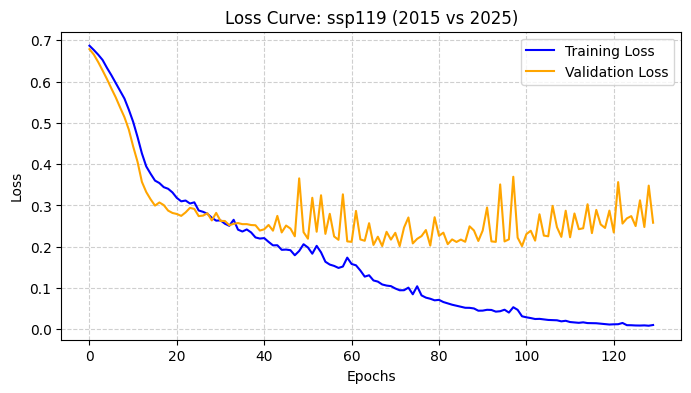

2/2 [==============================] - 0s 24ms/step
--> Iteration Accuracy: 80.00%
1/1 [==============================] - 0s 65ms/step
final accuracy:  80.00%
Processing: ssp119 | Early: 2015 | Late: 2035
processing model: CNRM_ESM2-1


C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 [==============================] - 2s 136ms/step - loss: 0.6909 - accuracy: 0.5000 - val_loss: 0.6791 - val_accuracy: 0.5000
Epoch 2/500
7/7 [==============================] - 1s 111ms/step - loss: 0.6719 - accuracy: 0.5000 - val_loss: 0.6623 - val_accuracy: 0.5000
Epoch 3/500
7/7 [==============================] - 1s 120ms/step - loss: 0.6522 - accuracy: 0.5000 - val_loss: 0.6410 - val_accuracy: 0.5000
Epoch 4/500
7/7 [==============================] - 1s 121ms/step - loss: 0.6239 - accuracy: 0.5075 - val_loss: 0.6132 - val_accuracy: 0.5200
Epoch 5/500
7/7 [==============================] - 1s 120ms/step - loss: 0.5905 - accuracy: 0.5600 - val_loss: 0.5770 - val_accuracy: 0.6000
Epoch 6/500
7/7 [==============================] - 1s 120ms/step - loss: 0.5480 - accuracy: 0.6975 - val_loss: 0.5331 - val_accuracy: 0.7200
Epoch 7/500
7/7 [=====================

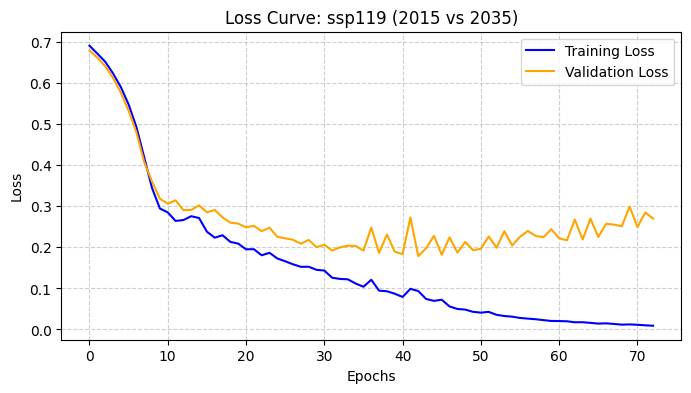

2/2 [==============================] - 0s 20ms/step
--> Iteration Accuracy: 90.00%
1/1 [==============================] - 0s 22ms/step
final accuracy:  90.00%
Processing: ssp119 | Early: 2015 | Late: 2045
processing model: CNRM_ESM2-1


C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 [==============================] - 2s 136ms/step - loss: 0.6930 - accuracy: 0.5525 - val_loss: 0.6911 - val_accuracy: 0.6200
Epoch 2/500
7/7 [==============================] - 1s 104ms/step - loss: 0.6872 - accuracy: 0.7350 - val_loss: 0.6885 - val_accuracy: 0.6400
Epoch 3/500
7/7 [==============================] - 1s 112ms/step - loss: 0.6821 - accuracy: 0.8150 - val_loss: 0.6837 - val_accuracy: 0.7200
Epoch 4/500
7/7 [==============================] - 1s 114ms/step - loss: 0.6746 - accuracy: 0.8725 - val_loss: 0.6757 - val_accuracy: 0.7800
Epoch 5/500
7/7 [==============================] - 1s 108ms/step - loss: 0.6632 - accuracy: 0.8575 - val_loss: 0.6640 - val_accuracy: 0.8000
Epoch 6/500
7/7 [==============================] - 1s 112ms/step - loss: 0.6435 - accuracy: 0.8500 - val_loss: 0.6424 - val_accuracy: 0.8000
Epoch 7/500
7/7 [=====================

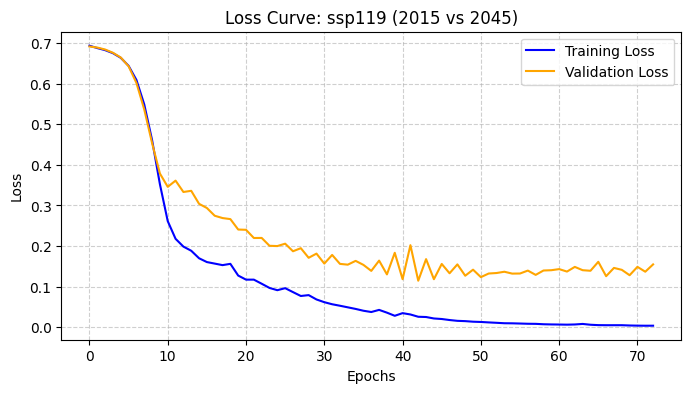

2/2 [==============================] - 0s 19ms/step
--> Iteration Accuracy: 92.00%
1/1 [==============================] - 0s 24ms/step
final accuracy:  92.00%
Processing: ssp119 | Early: 2015 | Late: 2055
processing model: CNRM_ESM2-1


C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 [==============================] - 2s 134ms/step - loss: 0.6913 - accuracy: 0.5050 - val_loss: 0.6898 - val_accuracy: 0.5000
Epoch 2/500
7/7 [==============================] - 1s 103ms/step - loss: 0.6863 - accuracy: 0.5100 - val_loss: 0.6862 - val_accuracy: 0.5400
Epoch 3/500
7/7 [==============================] - 1s 115ms/step - loss: 0.6799 - accuracy: 0.5775 - val_loss: 0.6807 - val_accuracy: 0.5800
Epoch 4/500
7/7 [==============================] - 1s 107ms/step - loss: 0.6708 - accuracy: 0.6550 - val_loss: 0.6721 - val_accuracy: 0.6400
Epoch 5/500
7/7 [==============================] - 1s 118ms/step - loss: 0.6555 - accuracy: 0.6925 - val_loss: 0.6580 - val_accuracy: 0.6600
Epoch 6/500
7/7 [==============================] - 1s 115ms/step - loss: 0.6321 - accuracy: 0.7500 - val_loss: 0.6358 - val_accuracy: 0.6800
Epoch 7/500
7/7 [=====================

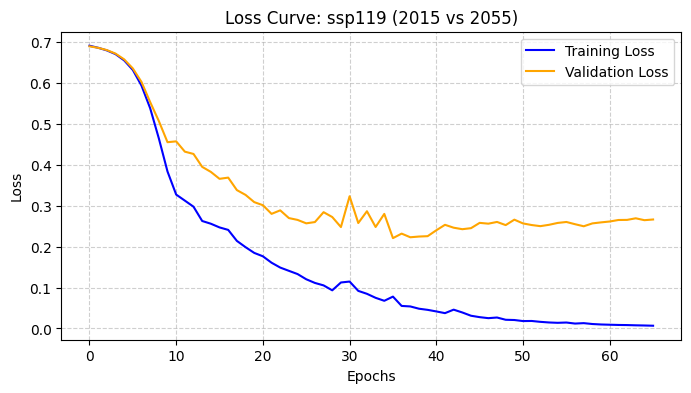

2/2 [==============================] - 0s 20ms/step
--> Iteration Accuracy: 98.00%
1/1 [==============================] - 0s 22ms/step
final accuracy:  98.00%
Processing: ssp119 | Early: 2015 | Late: 2065
processing model: CNRM_ESM2-1


C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 [==============================] - 2s 136ms/step - loss: 0.6859 - accuracy: 0.6275 - val_loss: 0.6836 - val_accuracy: 0.5200
Epoch 2/500
7/7 [==============================] - 1s 103ms/step - loss: 0.6722 - accuracy: 0.5725 - val_loss: 0.6752 - val_accuracy: 0.5200
Epoch 3/500
7/7 [==============================] - 1s 110ms/step - loss: 0.6549 - accuracy: 0.5450 - val_loss: 0.6633 - val_accuracy: 0.5200
Epoch 4/500
7/7 [==============================] - 1s 111ms/step - loss: 0.6293 - accuracy: 0.5500 - val_loss: 0.6492 - val_accuracy: 0.5400
Epoch 5/500
7/7 [==============================] - 1s 113ms/step - loss: 0.5946 - accuracy: 0.6275 - val_loss: 0.6298 - val_accuracy: 0.6200
Epoch 6/500
7/7 [==============================] - 1s 118ms/step - loss: 0.5491 - accuracy: 0.7300 - val_loss: 0.6046 - val_accuracy: 0.6600
Epoch 7/500
7/7 [=====================

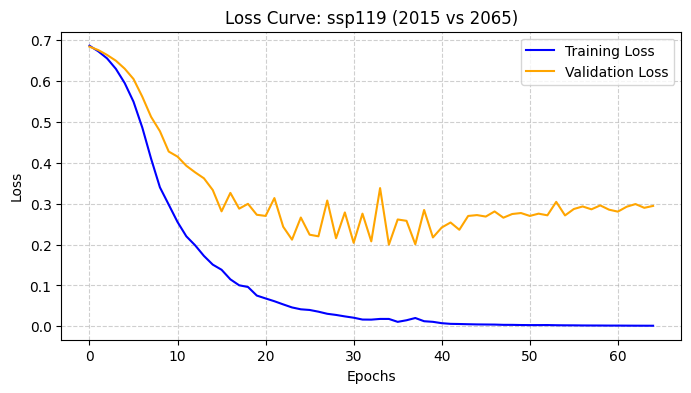

2/2 [==============================] - 0s 20ms/step
--> Iteration Accuracy: 94.00%
1/1 [==============================] - 0s 35ms/step
final accuracy:  94.00%
Processing: ssp119 | Early: 2015 | Late: 2075
processing model: CNRM_ESM2-1


C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 [==============================] - 2s 141ms/step - loss: 0.6826 - accuracy: 0.5000 - val_loss: 0.6748 - val_accuracy: 0.5000
Epoch 2/500
7/7 [==============================] - 1s 105ms/step - loss: 0.6697 - accuracy: 0.5000 - val_loss: 0.6616 - val_accuracy: 0.5000
Epoch 3/500
7/7 [==============================] - 1s 106ms/step - loss: 0.6545 - accuracy: 0.5000 - val_loss: 0.6491 - val_accuracy: 0.5000
Epoch 4/500
7/7 [==============================] - 1s 108ms/step - loss: 0.6399 - accuracy: 0.5000 - val_loss: 0.6385 - val_accuracy: 0.5000
Epoch 5/500
7/7 [==============================] - 1s 111ms/step - loss: 0.6245 - accuracy: 0.5000 - val_loss: 0.6286 - val_accuracy: 0.5000
Epoch 6/500
7/7 [==============================] - 1s 110ms/step - loss: 0.6117 - accuracy: 0.5000 - val_loss: 0.6177 - val_accuracy: 0.5000
Epoch 7/500
7/7 [=====================

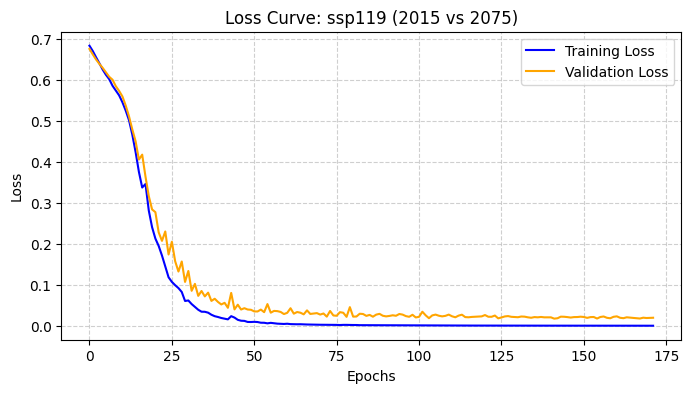

2/2 [==============================] - 0s 20ms/step
--> Iteration Accuracy: 98.00%
1/1 [==============================] - 0s 27ms/step
final accuracy:  98.00%
Processing: ssp119 | Early: 2015 | Late: 2085
processing model: CNRM_ESM2-1


C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 [==============================] - 2s 138ms/step - loss: 0.6907 - accuracy: 0.5025 - val_loss: 0.6834 - val_accuracy: 0.5000
Epoch 2/500
7/7 [==============================] - 1s 105ms/step - loss: 0.6803 - accuracy: 0.5450 - val_loss: 0.6761 - val_accuracy: 0.6000
Epoch 3/500
7/7 [==============================] - 1s 106ms/step - loss: 0.6705 - accuracy: 0.7050 - val_loss: 0.6662 - val_accuracy: 0.6600
Epoch 4/500
7/7 [==============================] - 1s 114ms/step - loss: 0.6556 - accuracy: 0.6925 - val_loss: 0.6528 - val_accuracy: 0.6400
Epoch 5/500
7/7 [==============================] - 1s 116ms/step - loss: 0.6303 - accuracy: 0.6700 - val_loss: 0.6258 - val_accuracy: 0.6600
Epoch 6/500
7/7 [==============================] - 1s 112ms/step - loss: 0.5932 - accuracy: 0.7575 - val_loss: 0.5971 - val_accuracy: 0.6400
Epoch 7/500
7/7 [=====================

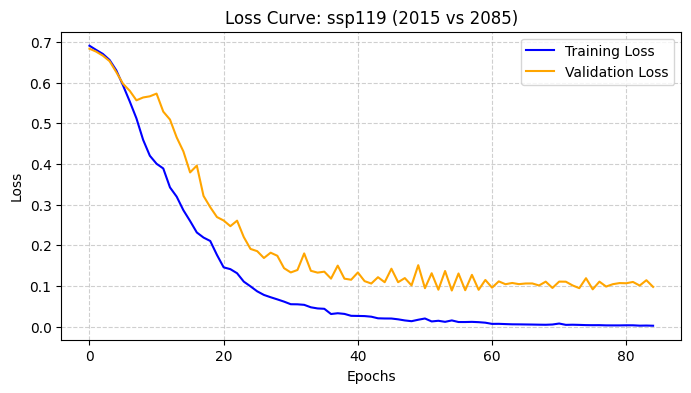

2/2 [==============================] - 0s 20ms/step
--> Iteration Accuracy: 98.00%
1/1 [==============================] - 0s 24ms/step
final accuracy:  98.00%
Processing: ssp119 | Early: 2025 | Late: 2035
processing model: CNRM_ESM2-1


C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 [==============================] - 2s 140ms/step - loss: 0.6924 - accuracy: 0.5000 - val_loss: 0.6919 - val_accuracy: 0.5000
Epoch 2/500
7/7 [==============================] - 1s 104ms/step - loss: 0.6903 - accuracy: 0.5000 - val_loss: 0.6909 - val_accuracy: 0.5000
Epoch 3/500
7/7 [==============================] - 1s 105ms/step - loss: 0.6886 - accuracy: 0.5000 - val_loss: 0.6902 - val_accuracy: 0.5000
Epoch 4/500
7/7 [==============================] - 1s 112ms/step - loss: 0.6865 - accuracy: 0.5000 - val_loss: 0.6893 - val_accuracy: 0.5000
Epoch 5/500
7/7 [==============================] - 1s 114ms/step - loss: 0.6849 - accuracy: 0.5000 - val_loss: 0.6885 - val_accuracy: 0.5000
Epoch 6/500
7/7 [==============================] - 1s 112ms/step - loss: 0.6826 - accuracy: 0.5000 - val_loss: 0.6871 - val_accuracy: 0.5000
Epoch 7/500
7/7 [=====================

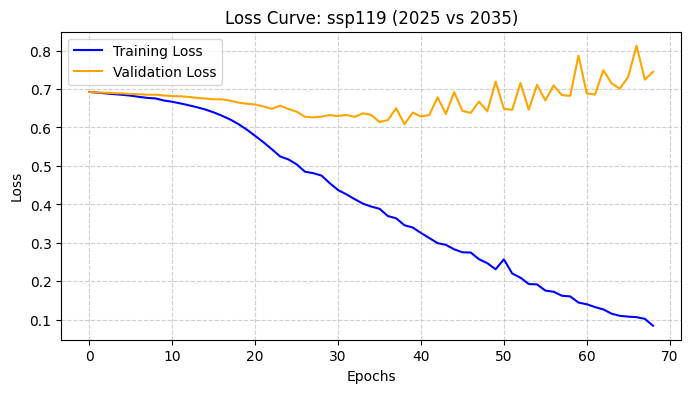

2/2 [==============================] - 0s 20ms/step
--> Iteration Accuracy: 68.00%
1/1 [==============================] - 0s 22ms/step
final accuracy:  68.00%
Processing: ssp119 | Early: 2025 | Late: 2045
processing model: CNRM_ESM2-1


C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 [==============================] - 2s 140ms/step - loss: 0.6920 - accuracy: 0.5025 - val_loss: 0.6899 - val_accuracy: 0.5000
Epoch 2/500
7/7 [==============================] - 1s 105ms/step - loss: 0.6864 - accuracy: 0.5000 - val_loss: 0.6881 - val_accuracy: 0.5000
Epoch 3/500
7/7 [==============================] - 1s 105ms/step - loss: 0.6830 - accuracy: 0.5000 - val_loss: 0.6874 - val_accuracy: 0.5000
Epoch 4/500
7/7 [==============================] - 1s 106ms/step - loss: 0.6797 - accuracy: 0.5075 - val_loss: 0.6871 - val_accuracy: 0.5000
Epoch 5/500
7/7 [==============================] - 1s 112ms/step - loss: 0.6757 - accuracy: 0.5100 - val_loss: 0.6858 - val_accuracy: 0.5000
Epoch 6/500
7/7 [==============================] - 1s 113ms/step - loss: 0.6731 - accuracy: 0.5100 - val_loss: 0.6849 - val_accuracy: 0.5000
Epoch 7/500
7/7 [=====================

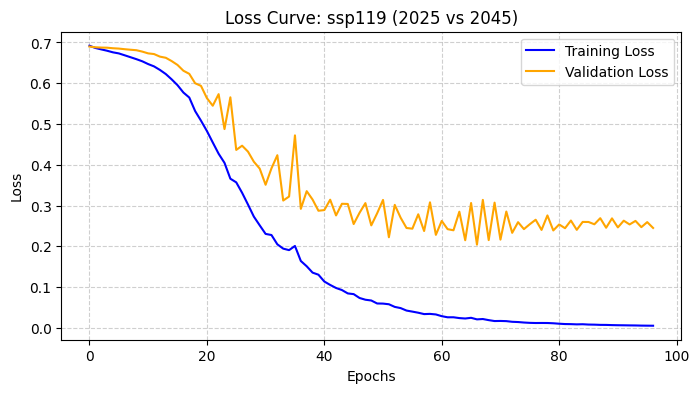

2/2 [==============================] - 0s 20ms/step
--> Iteration Accuracy: 84.00%
1/1 [==============================] - 0s 26ms/step
final accuracy:  84.00%
Processing: ssp119 | Early: 2025 | Late: 2055
processing model: CNRM_ESM2-1


C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 [==============================] - 2s 140ms/step - loss: 0.6939 - accuracy: 0.5000 - val_loss: 0.6924 - val_accuracy: 0.5000
Epoch 2/500
7/7 [==============================] - 1s 104ms/step - loss: 0.6913 - accuracy: 0.5075 - val_loss: 0.6917 - val_accuracy: 0.5000
Epoch 3/500
7/7 [==============================] - 1s 109ms/step - loss: 0.6895 - accuracy: 0.5100 - val_loss: 0.6906 - val_accuracy: 0.5000
Epoch 4/500
7/7 [==============================] - 1s 110ms/step - loss: 0.6873 - accuracy: 0.5300 - val_loss: 0.6893 - val_accuracy: 0.5400
Epoch 5/500
7/7 [==============================] - 1s 112ms/step - loss: 0.6842 - accuracy: 0.5675 - val_loss: 0.6872 - val_accuracy: 0.5200
Epoch 6/500
7/7 [==============================] - 1s 112ms/step - loss: 0.6802 - accuracy: 0.6050 - val_loss: 0.6844 - val_accuracy: 0.5200
Epoch 7/500
7/7 [=====================

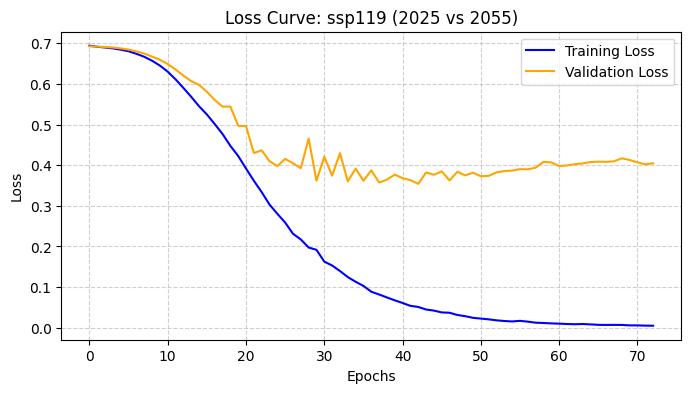

2/2 [==============================] - 0s 19ms/step
--> Iteration Accuracy: 86.00%
1/1 [==============================] - 0s 24ms/step
final accuracy:  86.00%
Processing: ssp119 | Early: 2025 | Late: 2065
processing model: CNRM_ESM2-1


C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 [==============================] - 2s 142ms/step - loss: 0.6937 - accuracy: 0.5000 - val_loss: 0.6926 - val_accuracy: 0.5000
Epoch 2/500
7/7 [==============================] - 1s 105ms/step - loss: 0.6921 - accuracy: 0.5000 - val_loss: 0.6922 - val_accuracy: 0.5000
Epoch 3/500
7/7 [==============================] - 1s 104ms/step - loss: 0.6907 - accuracy: 0.5150 - val_loss: 0.6922 - val_accuracy: 0.5000
Epoch 4/500
7/7 [==============================] - 1s 111ms/step - loss: 0.6895 - accuracy: 0.5350 - val_loss: 0.6913 - val_accuracy: 0.5000
Epoch 5/500
7/7 [==============================] - 1s 114ms/step - loss: 0.6879 - accuracy: 0.5475 - val_loss: 0.6911 - val_accuracy: 0.5000
Epoch 6/500
7/7 [==============================] - 1s 115ms/step - loss: 0.6856 - accuracy: 0.5725 - val_loss: 0.6902 - val_accuracy: 0.5000
Epoch 7/500
7/7 [=====================

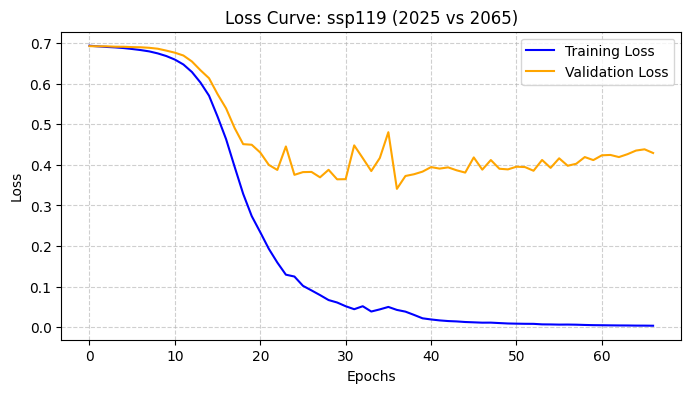

2/2 [==============================] - 0s 20ms/step
--> Iteration Accuracy: 90.00%
1/1 [==============================] - 0s 24ms/step
final accuracy:  90.00%
Processing: ssp119 | Early: 2025 | Late: 2075
processing model: CNRM_ESM2-1


C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 [==============================] - 2s 144ms/step - loss: 0.6936 - accuracy: 0.5150 - val_loss: 0.6921 - val_accuracy: 0.5400
Epoch 2/500
7/7 [==============================] - 1s 106ms/step - loss: 0.6917 - accuracy: 0.5825 - val_loss: 0.6910 - val_accuracy: 0.6000
Epoch 3/500
7/7 [==============================] - 1s 104ms/step - loss: 0.6900 - accuracy: 0.6100 - val_loss: 0.6905 - val_accuracy: 0.6400
Epoch 4/500
7/7 [==============================] - 1s 108ms/step - loss: 0.6884 - accuracy: 0.6675 - val_loss: 0.6896 - val_accuracy: 0.6200
Epoch 5/500
7/7 [==============================] - 1s 110ms/step - loss: 0.6864 - accuracy: 0.6700 - val_loss: 0.6882 - val_accuracy: 0.6200
Epoch 6/500
7/7 [==============================] - 1s 111ms/step - loss: 0.6836 - accuracy: 0.6625 - val_loss: 0.6855 - val_accuracy: 0.6000
Epoch 7/500
7/7 [=====================

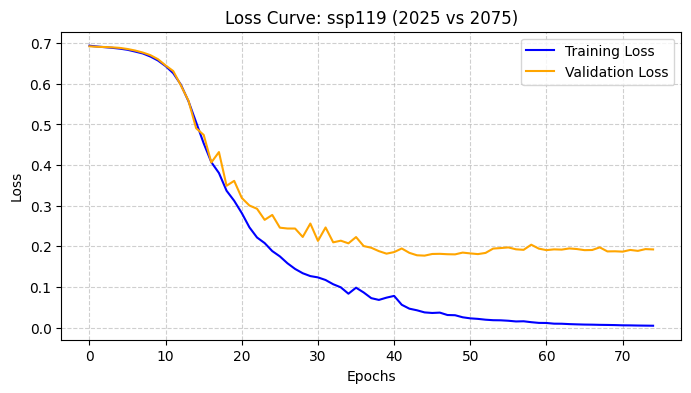

2/2 [==============================] - 0s 22ms/step
--> Iteration Accuracy: 96.00%
1/1 [==============================] - 0s 24ms/step
final accuracy:  96.00%
Processing: ssp119 | Early: 2025 | Late: 2085
processing model: CNRM_ESM2-1


C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 [==============================] - 2s 164ms/step - loss: 0.6935 - accuracy: 0.4850 - val_loss: 0.6936 - val_accuracy: 0.4600
Epoch 2/500
7/7 [==============================] - 1s 110ms/step - loss: 0.6923 - accuracy: 0.5050 - val_loss: 0.6929 - val_accuracy: 0.4600
Epoch 3/500
7/7 [==============================] - 1s 112ms/step - loss: 0.6913 - accuracy: 0.5050 - val_loss: 0.6924 - val_accuracy: 0.4800
Epoch 4/500
7/7 [==============================] - 1s 110ms/step - loss: 0.6900 - accuracy: 0.5450 - val_loss: 0.6922 - val_accuracy: 0.5000
Epoch 5/500
7/7 [==============================] - 1s 120ms/step - loss: 0.6884 - accuracy: 0.5775 - val_loss: 0.6921 - val_accuracy: 0.5400
Epoch 6/500
7/7 [==============================] - 1s 114ms/step - loss: 0.6857 - accuracy: 0.6300 - val_loss: 0.6914 - val_accuracy: 0.5200
Epoch 7/500
7/7 [=====================

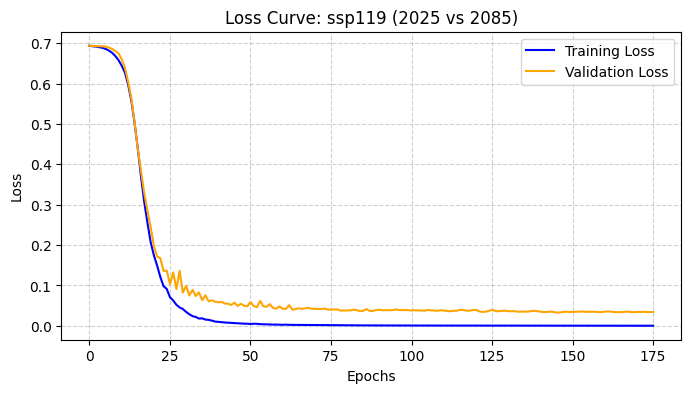

2/2 [==============================] - 0s 70ms/step
--> Iteration Accuracy: 96.00%
1/1 [==============================] - 0s 28ms/step
final accuracy:  96.00%
Processing: ssp119 | Early: 2035 | Late: 2045
processing model: CNRM_ESM2-1


C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 [==============================] - 5s 473ms/step - loss: 0.6929 - accuracy: 0.5150 - val_loss: 0.6938 - val_accuracy: 0.5400
Epoch 2/500
7/7 [==============================] - 3s 441ms/step - loss: 0.6914 - accuracy: 0.5125 - val_loss: 0.6939 - val_accuracy: 0.5400
Epoch 3/500
7/7 [==============================] - 3s 442ms/step - loss: 0.6902 - accuracy: 0.5125 - val_loss: 0.6942 - val_accuracy: 0.5000
Epoch 4/500
7/7 [==============================] - 3s 448ms/step - loss: 0.6894 - accuracy: 0.5000 - val_loss: 0.6947 - val_accuracy: 0.5000
Epoch 5/500
7/7 [==============================] - 3s 441ms/step - loss: 0.6875 - accuracy: 0.5050 - val_loss: 0.6939 - val_accuracy: 0.5200
Epoch 6/500
7/7 [==============================] - 3s 440ms/step - loss: 0.6867 - accuracy: 0.5375 - val_loss: 0.6944 - val_accuracy: 0.5400
Epoch 7/500
7/7 [=====================

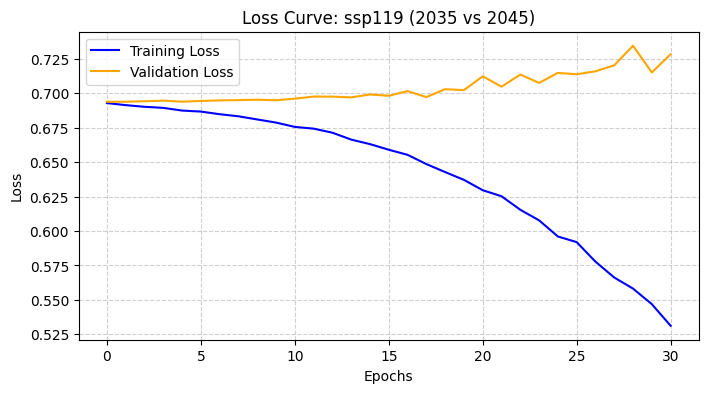

2/2 [==============================] - 0s 20ms/step
--> Iteration Accuracy: 46.00%
1/1 [==============================] - 0s 21ms/step
final accuracy:  46.00%
Processing: ssp119 | Early: 2035 | Late: 2055
processing model: CNRM_ESM2-1


C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 [==============================] - 2s 139ms/step - loss: 0.6934 - accuracy: 0.4600 - val_loss: 0.6932 - val_accuracy: 0.5400
Epoch 2/500
7/7 [==============================] - 1s 103ms/step - loss: 0.6921 - accuracy: 0.5850 - val_loss: 0.6932 - val_accuracy: 0.5000
Epoch 3/500
7/7 [==============================] - 1s 104ms/step - loss: 0.6912 - accuracy: 0.5675 - val_loss: 0.6931 - val_accuracy: 0.4600
Epoch 4/500
7/7 [==============================] - 1s 105ms/step - loss: 0.6904 - accuracy: 0.5625 - val_loss: 0.6929 - val_accuracy: 0.4200
Epoch 5/500
7/7 [==============================] - 1s 105ms/step - loss: 0.6895 - accuracy: 0.5675 - val_loss: 0.6927 - val_accuracy: 0.4200
Epoch 6/500
7/7 [==============================] - 1s 105ms/step - loss: 0.6885 - accuracy: 0.6100 - val_loss: 0.6923 - val_accuracy: 0.4600
Epoch 7/500
7/7 [=====================

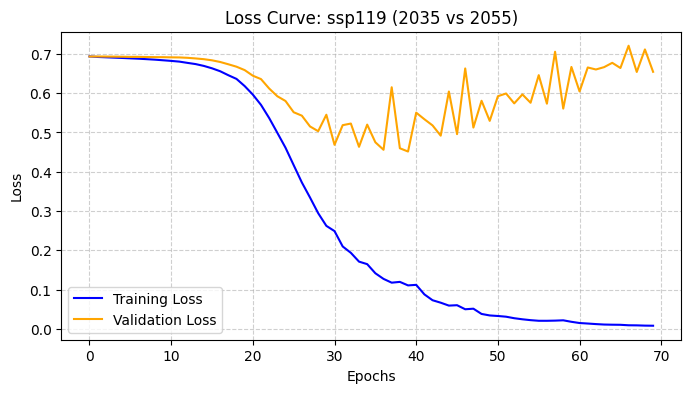

2/2 [==============================] - 0s 21ms/step
--> Iteration Accuracy: 84.00%
1/1 [==============================] - 0s 26ms/step
final accuracy:  84.00%
Processing: ssp119 | Early: 2035 | Late: 2065
processing model: CNRM_ESM2-1


C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 [==============================] - 2s 141ms/step - loss: 0.6922 - accuracy: 0.5175 - val_loss: 0.6913 - val_accuracy: 0.5000
Epoch 2/500
7/7 [==============================] - 1s 105ms/step - loss: 0.6900 - accuracy: 0.5175 - val_loss: 0.6912 - val_accuracy: 0.5000
Epoch 3/500
7/7 [==============================] - 1s 105ms/step - loss: 0.6880 - accuracy: 0.5300 - val_loss: 0.6899 - val_accuracy: 0.5800
Epoch 4/500
7/7 [==============================] - 1s 105ms/step - loss: 0.6856 - accuracy: 0.5750 - val_loss: 0.6890 - val_accuracy: 0.5800
Epoch 5/500
7/7 [==============================] - 1s 105ms/step - loss: 0.6832 - accuracy: 0.5825 - val_loss: 0.6875 - val_accuracy: 0.6000
Epoch 6/500
7/7 [==============================] - 1s 108ms/step - loss: 0.6803 - accuracy: 0.6000 - val_loss: 0.6856 - val_accuracy: 0.6200
Epoch 7/500
7/7 [=====================

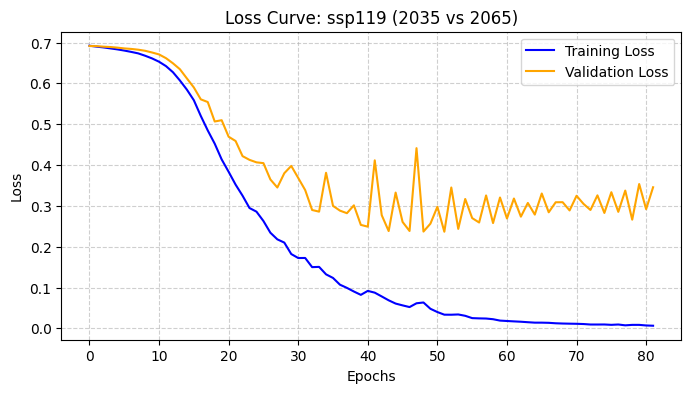

2/2 [==============================] - 0s 21ms/step
--> Iteration Accuracy: 88.00%
1/1 [==============================] - 0s 23ms/step
final accuracy:  88.00%
Processing: ssp119 | Early: 2035 | Late: 2075
processing model: CNRM_ESM2-1


C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 [==============================] - 2s 149ms/step - loss: 0.6920 - accuracy: 0.5000 - val_loss: 0.6890 - val_accuracy: 0.5000
Epoch 2/500
7/7 [==============================] - 1s 105ms/step - loss: 0.6893 - accuracy: 0.5000 - val_loss: 0.6874 - val_accuracy: 0.5000
Epoch 3/500
7/7 [==============================] - 1s 104ms/step - loss: 0.6867 - accuracy: 0.5000 - val_loss: 0.6851 - val_accuracy: 0.5000
Epoch 4/500
7/7 [==============================] - 1s 104ms/step - loss: 0.6837 - accuracy: 0.5100 - val_loss: 0.6817 - val_accuracy: 0.5000
Epoch 5/500
7/7 [==============================] - 1s 104ms/step - loss: 0.6794 - accuracy: 0.5275 - val_loss: 0.6770 - val_accuracy: 0.5000
Epoch 6/500
7/7 [==============================] - 1s 114ms/step - loss: 0.6745 - accuracy: 0.5250 - val_loss: 0.6705 - val_accuracy: 0.5000
Epoch 7/500
7/7 [=====================

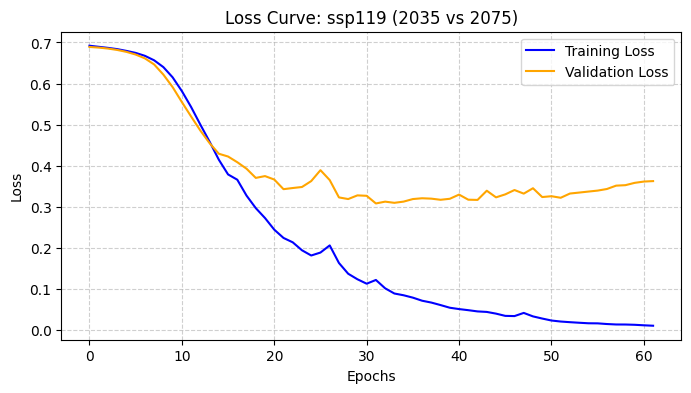

2/2 [==============================] - 0s 20ms/step
--> Iteration Accuracy: 88.00%
1/1 [==============================] - 0s 24ms/step
final accuracy:  88.00%
Processing: ssp119 | Early: 2035 | Late: 2085
processing model: CNRM_ESM2-1


C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 [==============================] - 2s 141ms/step - loss: 0.6894 - accuracy: 0.5150 - val_loss: 0.6845 - val_accuracy: 0.5000
Epoch 2/500
7/7 [==============================] - 1s 104ms/step - loss: 0.6824 - accuracy: 0.5150 - val_loss: 0.6800 - val_accuracy: 0.5200
Epoch 3/500
7/7 [==============================] - 1s 105ms/step - loss: 0.6760 - accuracy: 0.5250 - val_loss: 0.6769 - val_accuracy: 0.5200
Epoch 4/500
7/7 [==============================] - 1s 106ms/step - loss: 0.6669 - accuracy: 0.5325 - val_loss: 0.6707 - val_accuracy: 0.5600
Epoch 5/500
7/7 [==============================] - 1s 105ms/step - loss: 0.6556 - accuracy: 0.5525 - val_loss: 0.6611 - val_accuracy: 0.5600
Epoch 6/500
7/7 [==============================] - 1s 106ms/step - loss: 0.6423 - accuracy: 0.6000 - val_loss: 0.6467 - val_accuracy: 0.6000
Epoch 7/500
7/7 [=====================

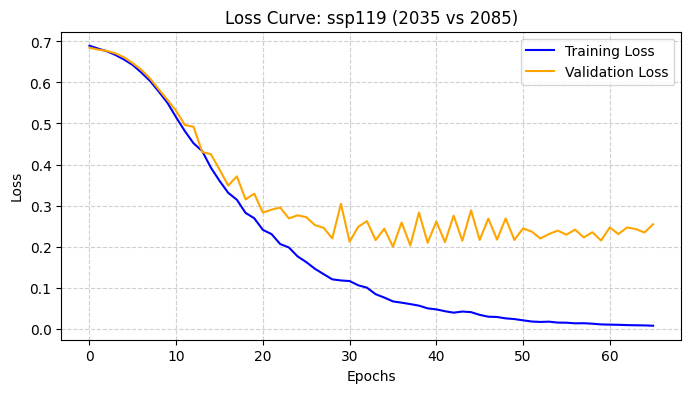

2/2 [==============================] - 0s 21ms/step
--> Iteration Accuracy: 92.00%
1/1 [==============================] - 0s 27ms/step
final accuracy:  92.00%
Processing: ssp119 | Early: 2045 | Late: 2055
processing model: CNRM_ESM2-1


C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 [==============================] - 2s 139ms/step - loss: 0.6935 - accuracy: 0.5000 - val_loss: 0.6934 - val_accuracy: 0.5000
Epoch 2/500
7/7 [==============================] - 1s 104ms/step - loss: 0.6927 - accuracy: 0.5000 - val_loss: 0.6933 - val_accuracy: 0.5000
Epoch 3/500
7/7 [==============================] - 1s 107ms/step - loss: 0.6922 - accuracy: 0.5000 - val_loss: 0.6932 - val_accuracy: 0.5000
Epoch 4/500
7/7 [==============================] - 1s 106ms/step - loss: 0.6916 - accuracy: 0.5025 - val_loss: 0.6930 - val_accuracy: 0.5000
Epoch 5/500
7/7 [==============================] - 1s 107ms/step - loss: 0.6909 - accuracy: 0.5125 - val_loss: 0.6933 - val_accuracy: 0.5000
Epoch 6/500
7/7 [==============================] - 1s 108ms/step - loss: 0.6901 - accuracy: 0.5225 - val_loss: 0.6931 - val_accuracy: 0.5000
Epoch 7/500
7/7 [=====================

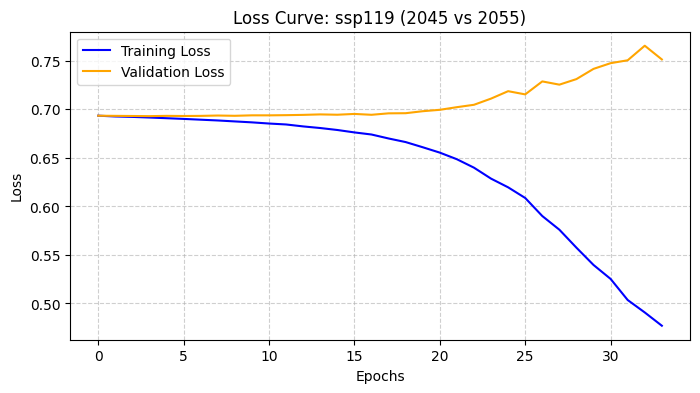

2/2 [==============================] - 0s 21ms/step
--> Iteration Accuracy: 50.00%
1/1 [==============================] - 0s 23ms/step
final accuracy:  50.00%
Processing: ssp119 | Early: 2045 | Late: 2065
processing model: CNRM_ESM2-1


C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 [==============================] - 2s 139ms/step - loss: 0.6932 - accuracy: 0.5025 - val_loss: 0.6928 - val_accuracy: 0.5200
Epoch 2/500
7/7 [==============================] - 1s 104ms/step - loss: 0.6913 - accuracy: 0.5125 - val_loss: 0.6930 - val_accuracy: 0.4800
Epoch 3/500
7/7 [==============================] - 1s 105ms/step - loss: 0.6899 - accuracy: 0.5575 - val_loss: 0.6927 - val_accuracy: 0.5600
Epoch 4/500
7/7 [==============================] - 1s 103ms/step - loss: 0.6885 - accuracy: 0.5900 - val_loss: 0.6929 - val_accuracy: 0.5400
Epoch 5/500
7/7 [==============================] - 1s 103ms/step - loss: 0.6872 - accuracy: 0.6050 - val_loss: 0.6930 - val_accuracy: 0.5200
Epoch 6/500
7/7 [==============================] - 1s 105ms/step - loss: 0.6849 - accuracy: 0.7000 - val_loss: 0.6926 - val_accuracy: 0.5000
Epoch 7/500
7/7 [=====================

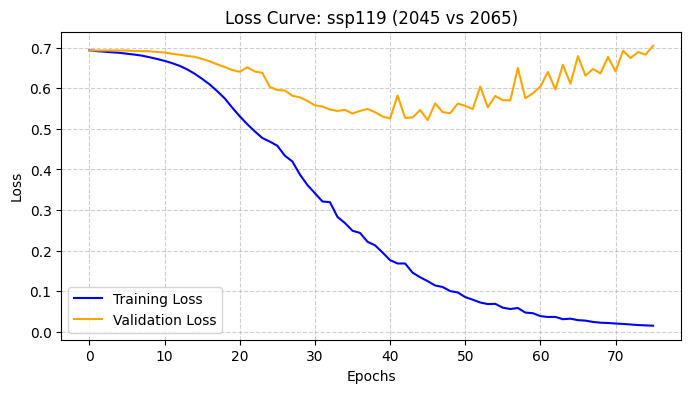

2/2 [==============================] - 0s 19ms/step
--> Iteration Accuracy: 78.00%
1/1 [==============================] - 0s 26ms/step
final accuracy:  78.00%
Processing: ssp119 | Early: 2045 | Late: 2075
processing model: CNRM_ESM2-1


C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 [==============================] - 3s 207ms/step - loss: 0.6959 - accuracy: 0.5000 - val_loss: 0.6948 - val_accuracy: 0.5000
Epoch 2/500
7/7 [==============================] - 1s 107ms/step - loss: 0.6912 - accuracy: 0.5000 - val_loss: 0.6930 - val_accuracy: 0.5000
Epoch 3/500
7/7 [==============================] - 1s 106ms/step - loss: 0.6892 - accuracy: 0.5025 - val_loss: 0.6921 - val_accuracy: 0.5000
Epoch 4/500
7/7 [==============================] - 1s 108ms/step - loss: 0.6881 - accuracy: 0.5325 - val_loss: 0.6918 - val_accuracy: 0.4600
Epoch 5/500
7/7 [==============================] - 1s 106ms/step - loss: 0.6859 - accuracy: 0.5250 - val_loss: 0.6918 - val_accuracy: 0.5000
Epoch 6/500
7/7 [==============================] - 1s 107ms/step - loss: 0.6835 - accuracy: 0.5200 - val_loss: 0.6919 - val_accuracy: 0.5000
Epoch 7/500
7/7 [=====================

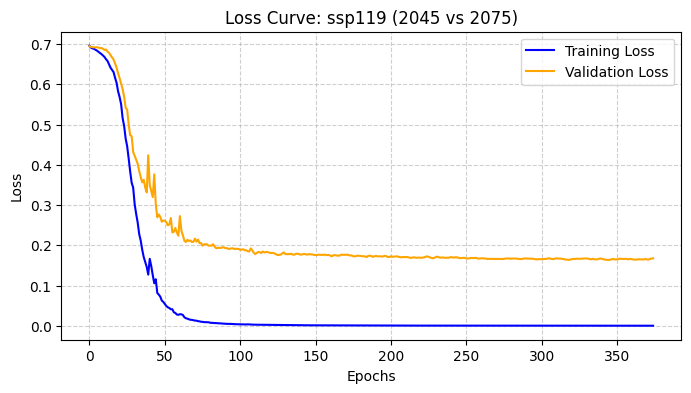

2/2 [==============================] - 0s 70ms/step
--> Iteration Accuracy: 90.00%
1/1 [==============================] - 0s 21ms/step
final accuracy:  90.00%
Processing: ssp119 | Early: 2045 | Late: 2085
processing model: CNRM_ESM2-1


C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 [==============================] - 4s 477ms/step - loss: 0.6917 - accuracy: 0.5000 - val_loss: 0.6884 - val_accuracy: 0.5000
Epoch 2/500
7/7 [==============================] - 3s 444ms/step - loss: 0.6864 - accuracy: 0.5000 - val_loss: 0.6851 - val_accuracy: 0.5000
Epoch 3/500
7/7 [==============================] - 3s 442ms/step - loss: 0.6819 - accuracy: 0.5000 - val_loss: 0.6801 - val_accuracy: 0.5200
Epoch 4/500
7/7 [==============================] - 3s 441ms/step - loss: 0.6777 - accuracy: 0.5375 - val_loss: 0.6736 - val_accuracy: 0.5600
Epoch 5/500
7/7 [==============================] - 3s 439ms/step - loss: 0.6714 - accuracy: 0.5850 - val_loss: 0.6679 - val_accuracy: 0.5800
Epoch 6/500
7/7 [==============================] - 3s 439ms/step - loss: 0.6647 - accuracy: 0.5900 - val_loss: 0.6595 - val_accuracy: 0.6400
Epoch 7/500
7/7 [=====================

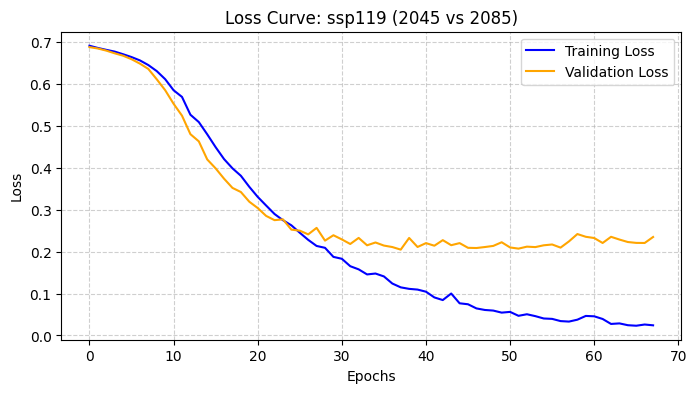

2/2 [==============================] - 0s 21ms/step
--> Iteration Accuracy: 86.00%
1/1 [==============================] - 0s 28ms/step
final accuracy:  86.00%
Processing: ssp119 | Early: 2055 | Late: 2065
processing model: CNRM_ESM2-1


C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 [==============================] - 2s 145ms/step - loss: 0.6931 - accuracy: 0.5000 - val_loss: 0.6943 - val_accuracy: 0.5000
Epoch 2/500
7/7 [==============================] - 1s 103ms/step - loss: 0.6913 - accuracy: 0.5000 - val_loss: 0.6945 - val_accuracy: 0.5000
Epoch 3/500
7/7 [==============================] - 1s 103ms/step - loss: 0.6900 - accuracy: 0.5000 - val_loss: 0.6948 - val_accuracy: 0.5000
Epoch 4/500
7/7 [==============================] - 1s 104ms/step - loss: 0.6886 - accuracy: 0.5000 - val_loss: 0.6948 - val_accuracy: 0.5000
Epoch 5/500
7/7 [==============================] - 1s 104ms/step - loss: 0.6865 - accuracy: 0.5000 - val_loss: 0.6951 - val_accuracy: 0.5000
Epoch 6/500
7/7 [==============================] - 1s 106ms/step - loss: 0.6844 - accuracy: 0.5000 - val_loss: 0.6946 - val_accuracy: 0.5000
Epoch 7/500
7/7 [=====================

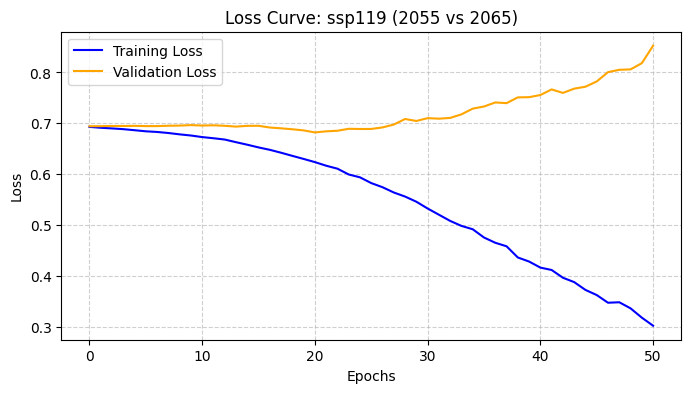

2/2 [==============================] - 0s 20ms/step
--> Iteration Accuracy: 54.00%
1/1 [==============================] - 0s 27ms/step
final accuracy:  54.00%
Processing: ssp119 | Early: 2055 | Late: 2075
processing model: CNRM_ESM2-1


C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 [==============================] - 2s 139ms/step - loss: 0.6932 - accuracy: 0.4900 - val_loss: 0.6933 - val_accuracy: 0.4800
Epoch 2/500
7/7 [==============================] - 1s 109ms/step - loss: 0.6925 - accuracy: 0.5600 - val_loss: 0.6931 - val_accuracy: 0.5400
Epoch 3/500
7/7 [==============================] - 1s 107ms/step - loss: 0.6920 - accuracy: 0.6125 - val_loss: 0.6931 - val_accuracy: 0.5600
Epoch 4/500
7/7 [==============================] - 1s 110ms/step - loss: 0.6912 - accuracy: 0.6550 - val_loss: 0.6926 - val_accuracy: 0.5400
Epoch 5/500
7/7 [==============================] - 1s 111ms/step - loss: 0.6904 - accuracy: 0.7150 - val_loss: 0.6928 - val_accuracy: 0.5400
Epoch 6/500
7/7 [==============================] - 1s 111ms/step - loss: 0.6895 - accuracy: 0.6975 - val_loss: 0.6922 - val_accuracy: 0.5000
Epoch 7/500
7/7 [=====================

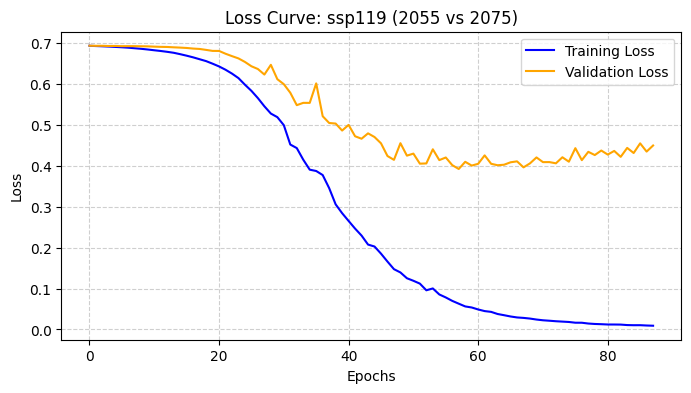

2/2 [==============================] - 0s 20ms/step
--> Iteration Accuracy: 84.00%
1/1 [==============================] - 0s 26ms/step
final accuracy:  84.00%
Processing: ssp119 | Early: 2055 | Late: 2085
processing model: CNRM_ESM2-1


C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 [==============================] - 3s 251ms/step - loss: 0.6899 - accuracy: 0.5800 - val_loss: 0.6904 - val_accuracy: 0.6200
Epoch 2/500
7/7 [==============================] - 1s 125ms/step - loss: 0.6836 - accuracy: 0.6800 - val_loss: 0.6868 - val_accuracy: 0.6400
Epoch 3/500
7/7 [==============================] - 1s 111ms/step - loss: 0.6776 - accuracy: 0.6950 - val_loss: 0.6822 - val_accuracy: 0.6000
Epoch 4/500
7/7 [==============================] - 1s 111ms/step - loss: 0.6712 - accuracy: 0.6975 - val_loss: 0.6785 - val_accuracy: 0.6000
Epoch 5/500
7/7 [==============================] - 1s 115ms/step - loss: 0.6633 - accuracy: 0.7100 - val_loss: 0.6729 - val_accuracy: 0.6400
Epoch 6/500
7/7 [==============================] - 1s 122ms/step - loss: 0.6534 - accuracy: 0.7225 - val_loss: 0.6679 - val_accuracy: 0.6400
Epoch 7/500
7/7 [=====================

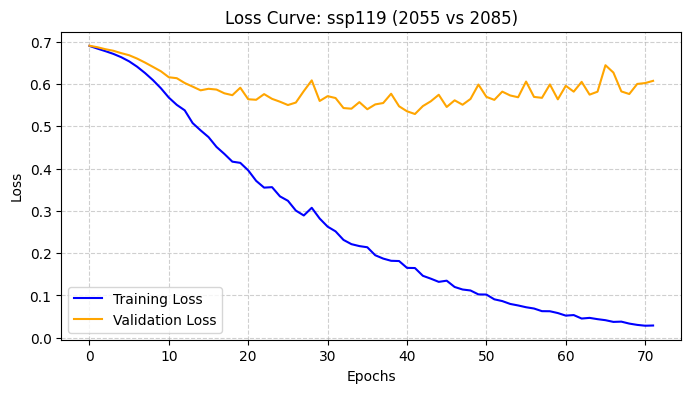

2/2 [==============================] - 0s 20ms/step
--> Iteration Accuracy: 74.00%
1/1 [==============================] - 0s 25ms/step
final accuracy:  74.00%
Processing: ssp119 | Early: 2065 | Late: 2075
processing model: CNRM_ESM2-1


C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 [==============================] - 4s 469ms/step - loss: 0.6940 - accuracy: 0.4900 - val_loss: 0.6945 - val_accuracy: 0.4800
Epoch 2/500
7/7 [==============================] - 3s 441ms/step - loss: 0.6920 - accuracy: 0.5225 - val_loss: 0.6943 - val_accuracy: 0.4800
Epoch 3/500
7/7 [==============================] - 3s 441ms/step - loss: 0.6908 - accuracy: 0.5350 - val_loss: 0.6944 - val_accuracy: 0.4800
Epoch 4/500
7/7 [==============================] - 3s 441ms/step - loss: 0.6897 - accuracy: 0.5500 - val_loss: 0.6947 - val_accuracy: 0.4600
Epoch 5/500
7/7 [==============================] - 3s 441ms/step - loss: 0.6881 - accuracy: 0.5775 - val_loss: 0.6939 - val_accuracy: 0.4800
Epoch 6/500
7/7 [==============================] - 3s 440ms/step - loss: 0.6867 - accuracy: 0.6100 - val_loss: 0.6944 - val_accuracy: 0.4600
Epoch 7/500
7/7 [=====================

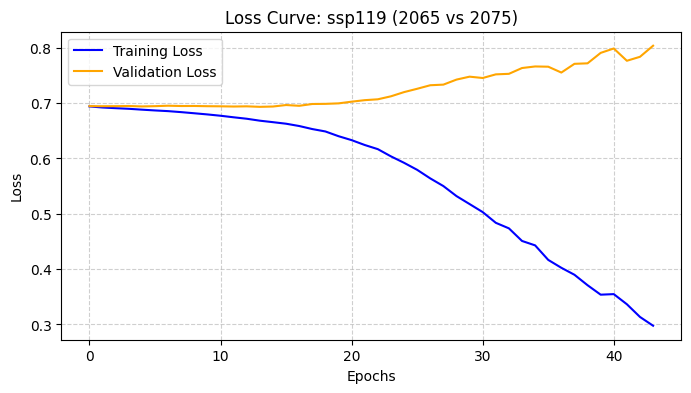

2/2 [==============================] - 0s 70ms/step
--> Iteration Accuracy: 40.00%
1/1 [==============================] - 0s 23ms/step
final accuracy:  40.00%
Processing: ssp119 | Early: 2065 | Late: 2085
processing model: CNRM_ESM2-1


C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 [==============================] - 4s 472ms/step - loss: 0.6961 - accuracy: 0.5000 - val_loss: 0.6926 - val_accuracy: 0.5000
Epoch 2/500
7/7 [==============================] - 3s 442ms/step - loss: 0.6928 - accuracy: 0.5000 - val_loss: 0.6919 - val_accuracy: 0.5000
Epoch 3/500
7/7 [==============================] - 3s 443ms/step - loss: 0.6911 - accuracy: 0.5000 - val_loss: 0.6915 - val_accuracy: 0.5000
Epoch 4/500
7/7 [==============================] - 3s 440ms/step - loss: 0.6894 - accuracy: 0.5000 - val_loss: 0.6917 - val_accuracy: 0.5000
Epoch 5/500
7/7 [==============================] - 3s 442ms/step - loss: 0.6878 - accuracy: 0.5000 - val_loss: 0.6912 - val_accuracy: 0.5000
Epoch 6/500
7/7 [==============================] - 3s 444ms/step - loss: 0.6863 - accuracy: 0.5000 - val_loss: 0.6910 - val_accuracy: 0.5000
Epoch 7/500
7/7 [=====================

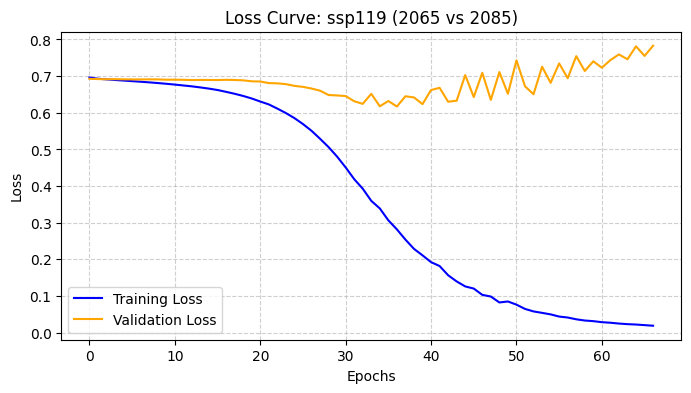

2/2 [==============================] - 0s 17ms/step
--> Iteration Accuracy: 68.00%
1/1 [==============================] - 0s 23ms/step
final accuracy:  68.00%
Processing: ssp119 | Early: 2075 | Late: 2085
processing model: CNRM_ESM2-1


C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 [==============================] - 2s 173ms/step - loss: 0.6931 - accuracy: 0.5075 - val_loss: 0.6917 - val_accuracy: 0.5000
Epoch 2/500
7/7 [==============================] - 1s 137ms/step - loss: 0.6919 - accuracy: 0.5350 - val_loss: 0.6915 - val_accuracy: 0.5400
Epoch 3/500
7/7 [==============================] - 1s 136ms/step - loss: 0.6911 - accuracy: 0.5900 - val_loss: 0.6911 - val_accuracy: 0.5600
Epoch 4/500
7/7 [==============================] - 1s 137ms/step - loss: 0.6901 - accuracy: 0.6050 - val_loss: 0.6902 - val_accuracy: 0.6000
Epoch 5/500
7/7 [==============================] - 1s 135ms/step - loss: 0.6889 - accuracy: 0.6600 - val_loss: 0.6907 - val_accuracy: 0.5200
Epoch 6/500
7/7 [==============================] - 1s 137ms/step - loss: 0.6875 - accuracy: 0.6925 - val_loss: 0.6894 - val_accuracy: 0.5800
Epoch 7/500
7/7 [=====================

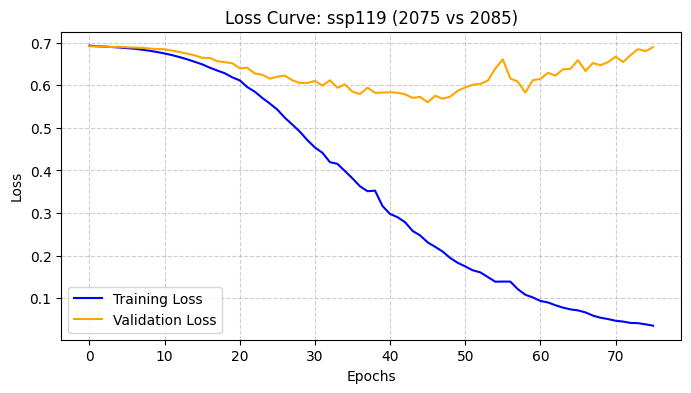

2/2 [==============================] - 0s 21ms/step
--> Iteration Accuracy: 74.00%
1/1 [==============================] - 0s 33ms/step
final accuracy:  74.00%
Processing: ssp126 | Early: 2015 | Late: 2025
processing model: CNRM_ESM2-1


C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 [==============================] - 2s 153ms/step - loss: 0.6919 - accuracy: 0.5525 - val_loss: 0.6920 - val_accuracy: 0.5000
Epoch 2/500
7/7 [==============================] - 1s 107ms/step - loss: 0.6885 - accuracy: 0.6600 - val_loss: 0.6909 - val_accuracy: 0.5400
Epoch 3/500
7/7 [==============================] - 1s 109ms/step - loss: 0.6846 - accuracy: 0.7250 - val_loss: 0.6892 - val_accuracy: 0.6200
Epoch 4/500
7/7 [==============================] - 1s 108ms/step - loss: 0.6795 - accuracy: 0.7700 - val_loss: 0.6866 - val_accuracy: 0.6200
Epoch 5/500
7/7 [==============================] - 1s 109ms/step - loss: 0.6710 - accuracy: 0.7700 - val_loss: 0.6821 - val_accuracy: 0.6200
Epoch 6/500
7/7 [==============================] - 1s 109ms/step - loss: 0.6578 - accuracy: 0.7775 - val_loss: 0.6756 - val_accuracy: 0.6400
Epoch 7/500
7/7 [=====================

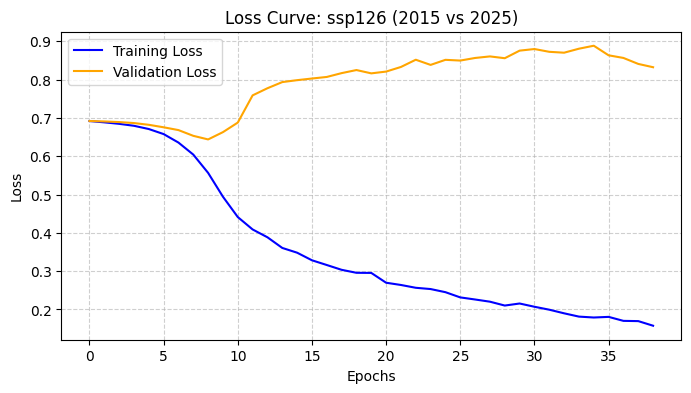

2/2 [==============================] - 0s 21ms/step
--> Iteration Accuracy: 78.00%
1/1 [==============================] - 0s 32ms/step
final accuracy:  78.00%
Processing: ssp126 | Early: 2015 | Late: 2035
processing model: CNRM_ESM2-1


C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 [==============================] - 2s 140ms/step - loss: 0.6849 - accuracy: 0.5000 - val_loss: 0.6744 - val_accuracy: 0.5000
Epoch 2/500
7/7 [==============================] - 1s 104ms/step - loss: 0.6659 - accuracy: 0.5000 - val_loss: 0.6459 - val_accuracy: 0.5000
Epoch 3/500
7/7 [==============================] - 1s 106ms/step - loss: 0.6404 - accuracy: 0.5000 - val_loss: 0.6072 - val_accuracy: 0.5000
Epoch 4/500
7/7 [==============================] - 1s 106ms/step - loss: 0.6098 - accuracy: 0.5000 - val_loss: 0.5697 - val_accuracy: 0.5000
Epoch 5/500
7/7 [==============================] - 1s 106ms/step - loss: 0.5779 - accuracy: 0.5025 - val_loss: 0.5336 - val_accuracy: 0.5200
Epoch 6/500
7/7 [==============================] - 1s 108ms/step - loss: 0.5497 - accuracy: 0.5050 - val_loss: 0.5050 - val_accuracy: 0.5600
Epoch 7/500
7/7 [=====================

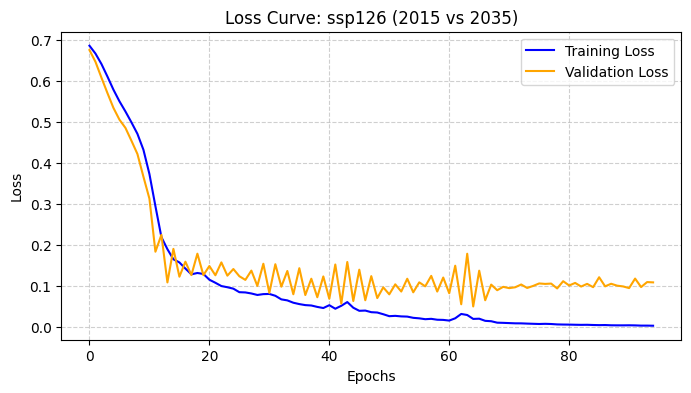

2/2 [==============================] - 0s 20ms/step
--> Iteration Accuracy: 94.00%
1/1 [==============================] - 0s 36ms/step
final accuracy:  94.00%
Processing: ssp126 | Early: 2015 | Late: 2045
processing model: CNRM_ESM2-1


C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 [==============================] - 2s 140ms/step - loss: 0.6927 - accuracy: 0.5825 - val_loss: 0.6882 - val_accuracy: 0.8000
Epoch 2/500
7/7 [==============================] - 1s 105ms/step - loss: 0.6877 - accuracy: 0.7800 - val_loss: 0.6839 - val_accuracy: 0.7000
Epoch 3/500
7/7 [==============================] - 1s 107ms/step - loss: 0.6811 - accuracy: 0.7950 - val_loss: 0.6766 - val_accuracy: 0.7000
Epoch 4/500
7/7 [==============================] - 1s 106ms/step - loss: 0.6714 - accuracy: 0.8200 - val_loss: 0.6634 - val_accuracy: 0.7400
Epoch 5/500
7/7 [==============================] - 1s 106ms/step - loss: 0.6547 - accuracy: 0.8175 - val_loss: 0.6430 - val_accuracy: 0.7000
Epoch 6/500
7/7 [==============================] - 1s 105ms/step - loss: 0.6274 - accuracy: 0.7450 - val_loss: 0.6046 - val_accuracy: 0.7400
Epoch 7/500
7/7 [=====================

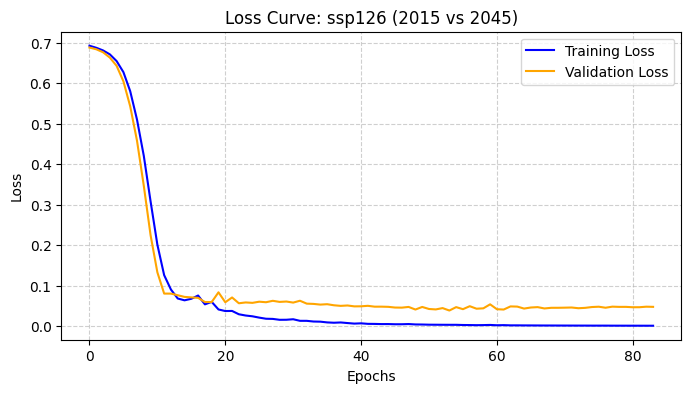

2/2 [==============================] - 0s 21ms/step
--> Iteration Accuracy: 96.00%
1/1 [==============================] - 0s 26ms/step
final accuracy:  96.00%
Processing: ssp126 | Early: 2015 | Late: 2055
processing model: CNRM_ESM2-1


C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 [==============================] - 2s 146ms/step - loss: 0.6787 - accuracy: 0.5000 - val_loss: 0.6457 - val_accuracy: 0.5000
Epoch 2/500
7/7 [==============================] - 1s 104ms/step - loss: 0.6389 - accuracy: 0.5000 - val_loss: 0.6092 - val_accuracy: 0.5000
Epoch 3/500
7/7 [==============================] - 1s 104ms/step - loss: 0.6007 - accuracy: 0.5000 - val_loss: 0.5755 - val_accuracy: 0.5000
Epoch 4/500
7/7 [==============================] - 1s 104ms/step - loss: 0.5726 - accuracy: 0.5000 - val_loss: 0.5521 - val_accuracy: 0.5000
Epoch 5/500
7/7 [==============================] - 1s 105ms/step - loss: 0.5384 - accuracy: 0.5000 - val_loss: 0.5194 - val_accuracy: 0.5000
Epoch 6/500
7/7 [==============================] - 1s 109ms/step - loss: 0.5133 - accuracy: 0.5075 - val_loss: 0.4953 - val_accuracy: 0.5400
Epoch 7/500
7/7 [=====================

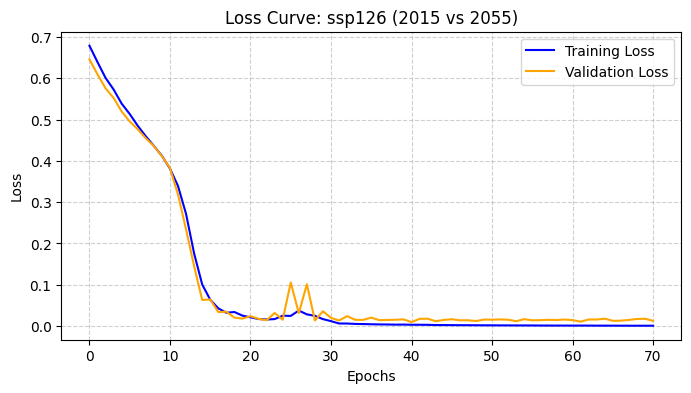

2/2 [==============================] - 0s 19ms/step
--> Iteration Accuracy: 98.00%
1/1 [==============================] - 0s 22ms/step
final accuracy:  98.00%
Processing: ssp126 | Early: 2015 | Late: 2065
processing model: CNRM_ESM2-1


C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 [==============================] - 2s 154ms/step - loss: 0.6926 - accuracy: 0.5825 - val_loss: 0.6881 - val_accuracy: 0.7000
Epoch 2/500
7/7 [==============================] - 1s 111ms/step - loss: 0.6838 - accuracy: 0.7825 - val_loss: 0.6801 - val_accuracy: 0.7600
Epoch 3/500
7/7 [==============================] - 1s 112ms/step - loss: 0.6716 - accuracy: 0.8300 - val_loss: 0.6653 - val_accuracy: 0.8200
Epoch 4/500
7/7 [==============================] - 1s 113ms/step - loss: 0.6508 - accuracy: 0.8425 - val_loss: 0.6389 - val_accuracy: 0.8400
Epoch 5/500
7/7 [==============================] - 1s 128ms/step - loss: 0.6146 - accuracy: 0.8575 - val_loss: 0.5924 - val_accuracy: 0.8600
Epoch 6/500
7/7 [==============================] - 1s 130ms/step - loss: 0.5562 - accuracy: 0.8675 - val_loss: 0.5234 - val_accuracy: 0.9000
Epoch 7/500
7/7 [=====================

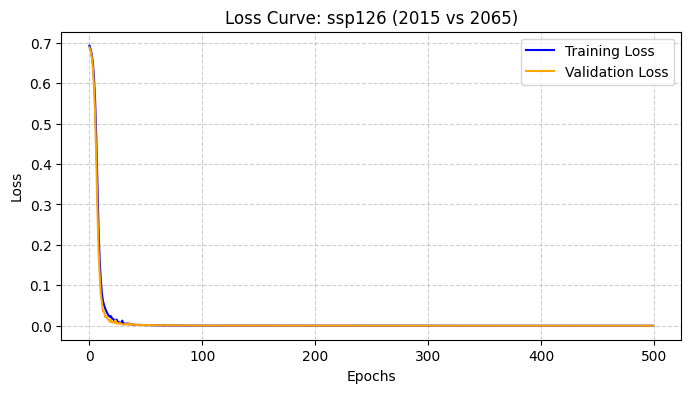

2/2 [==============================] - 0s 69ms/step
--> Iteration Accuracy: 100.00%
1/1 [==============================] - 0s 21ms/step
final accuracy:  100.00%
Processing: ssp126 | Early: 2015 | Late: 2075
processing model: CNRM_ESM2-1


C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 [==============================] - 2s 167ms/step - loss: 0.6980 - accuracy: 0.5000 - val_loss: 0.6898 - val_accuracy: 0.5000
Epoch 2/500
7/7 [==============================] - 1s 134ms/step - loss: 0.6857 - accuracy: 0.5275 - val_loss: 0.6796 - val_accuracy: 0.6200
Epoch 3/500
7/7 [==============================] - 1s 135ms/step - loss: 0.6726 - accuracy: 0.6950 - val_loss: 0.6660 - val_accuracy: 0.6800
Epoch 4/500
7/7 [==============================] - 1s 134ms/step - loss: 0.6523 - accuracy: 0.7350 - val_loss: 0.6388 - val_accuracy: 0.7200
Epoch 5/500
7/7 [==============================] - 1s 134ms/step - loss: 0.6152 - accuracy: 0.7700 - val_loss: 0.5922 - val_accuracy: 0.7400
Epoch 6/500
7/7 [==============================] - 1s 136ms/step - loss: 0.5546 - accuracy: 0.7675 - val_loss: 0.5215 - val_accuracy: 0.7400
Epoch 7/500
7/7 [=====================

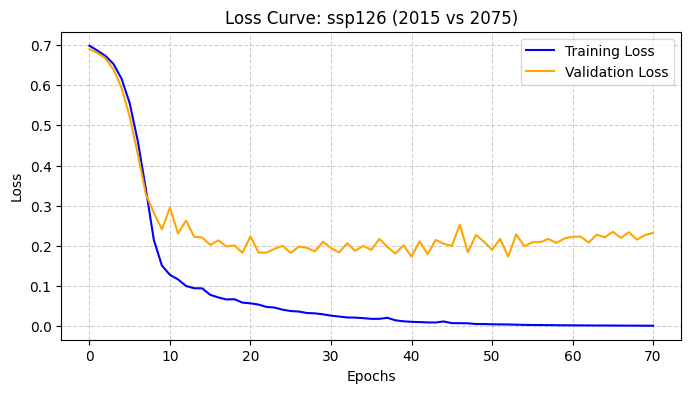

2/2 [==============================] - 0s 20ms/step
--> Iteration Accuracy: 100.00%
1/1 [==============================] - 0s 26ms/step
final accuracy:  100.00%
Processing: ssp126 | Early: 2015 | Late: 2085
processing model: CNRM_ESM2-1


C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 [==============================] - 2s 142ms/step - loss: 0.6909 - accuracy: 0.6825 - val_loss: 0.6870 - val_accuracy: 0.8600
Epoch 2/500
7/7 [==============================] - 1s 105ms/step - loss: 0.6850 - accuracy: 0.8575 - val_loss: 0.6791 - val_accuracy: 0.9000
Epoch 3/500
7/7 [==============================] - 1s 106ms/step - loss: 0.6755 - accuracy: 0.8800 - val_loss: 0.6646 - val_accuracy: 0.8800
Epoch 4/500
7/7 [==============================] - 1s 106ms/step - loss: 0.6581 - accuracy: 0.8975 - val_loss: 0.6360 - val_accuracy: 0.9000
Epoch 5/500
7/7 [==============================] - 1s 107ms/step - loss: 0.6223 - accuracy: 0.8975 - val_loss: 0.5826 - val_accuracy: 0.9000
Epoch 6/500
7/7 [==============================] - 1s 110ms/step - loss: 0.5591 - accuracy: 0.8750 - val_loss: 0.4915 - val_accuracy: 0.9200
Epoch 7/500
7/7 [=====================

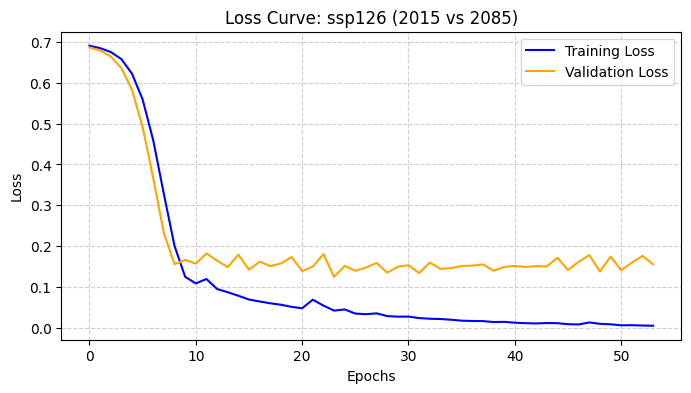

2/2 [==============================] - 0s 22ms/step
--> Iteration Accuracy: 86.00%
1/1 [==============================] - 0s 28ms/step
final accuracy:  86.00%
Processing: ssp126 | Early: 2025 | Late: 2035
processing model: CNRM_ESM2-1


C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 [==============================] - 2s 141ms/step - loss: 0.6903 - accuracy: 0.5000 - val_loss: 0.6893 - val_accuracy: 0.5000
Epoch 2/500
7/7 [==============================] - 1s 104ms/step - loss: 0.6861 - accuracy: 0.5000 - val_loss: 0.6876 - val_accuracy: 0.5000
Epoch 3/500
7/7 [==============================] - 1s 103ms/step - loss: 0.6821 - accuracy: 0.5000 - val_loss: 0.6851 - val_accuracy: 0.5000
Epoch 4/500
7/7 [==============================] - 1s 105ms/step - loss: 0.6783 - accuracy: 0.5000 - val_loss: 0.6818 - val_accuracy: 0.5000
Epoch 5/500
7/7 [==============================] - 1s 105ms/step - loss: 0.6740 - accuracy: 0.5000 - val_loss: 0.6785 - val_accuracy: 0.5000
Epoch 6/500
7/7 [==============================] - 1s 105ms/step - loss: 0.6674 - accuracy: 0.5125 - val_loss: 0.6721 - val_accuracy: 0.5400
Epoch 7/500
7/7 [=====================

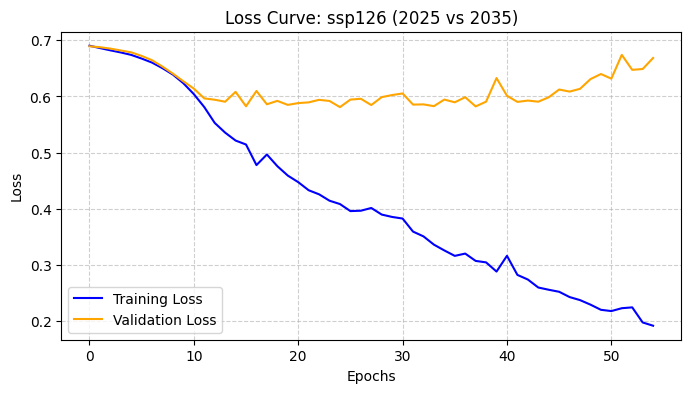

2/2 [==============================] - 0s 20ms/step
--> Iteration Accuracy: 72.00%
1/1 [==============================] - 0s 23ms/step
final accuracy:  72.00%
Processing: ssp126 | Early: 2025 | Late: 2045
processing model: CNRM_ESM2-1


C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 [==============================] - 2s 143ms/step - loss: 0.6945 - accuracy: 0.5050 - val_loss: 0.6922 - val_accuracy: 0.5200
Epoch 2/500
7/7 [==============================] - 1s 105ms/step - loss: 0.6899 - accuracy: 0.6150 - val_loss: 0.6905 - val_accuracy: 0.5800
Epoch 3/500
7/7 [==============================] - 1s 105ms/step - loss: 0.6866 - accuracy: 0.6925 - val_loss: 0.6883 - val_accuracy: 0.6400
Epoch 4/500
7/7 [==============================] - 1s 105ms/step - loss: 0.6827 - accuracy: 0.7400 - val_loss: 0.6862 - val_accuracy: 0.6400
Epoch 5/500
7/7 [==============================] - 1s 106ms/step - loss: 0.6779 - accuracy: 0.7950 - val_loss: 0.6820 - val_accuracy: 0.6800
Epoch 6/500
7/7 [==============================] - 1s 109ms/step - loss: 0.6712 - accuracy: 0.8025 - val_loss: 0.6770 - val_accuracy: 0.7000
Epoch 7/500
7/7 [=====================

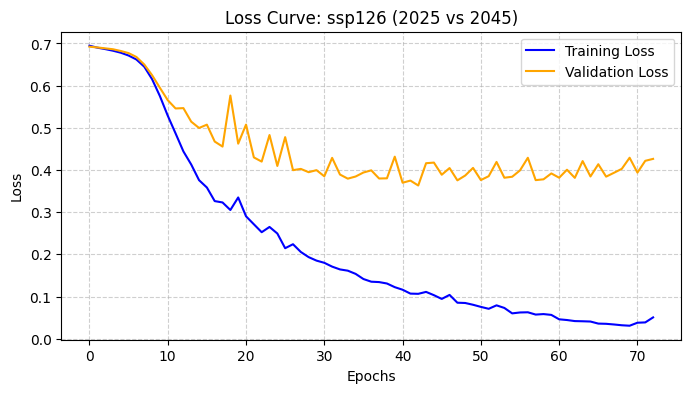

2/2 [==============================] - 0s 19ms/step
--> Iteration Accuracy: 94.00%
1/1 [==============================] - 0s 24ms/step
final accuracy:  94.00%
Processing: ssp126 | Early: 2025 | Late: 2055
processing model: CNRM_ESM2-1


C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 [==============================] - 2s 144ms/step - loss: 0.6972 - accuracy: 0.5000 - val_loss: 0.6948 - val_accuracy: 0.5000
Epoch 2/500
7/7 [==============================] - 1s 106ms/step - loss: 0.6904 - accuracy: 0.5300 - val_loss: 0.6908 - val_accuracy: 0.5400
Epoch 3/500
7/7 [==============================] - 1s 106ms/step - loss: 0.6856 - accuracy: 0.5425 - val_loss: 0.6864 - val_accuracy: 0.5400
Epoch 4/500
7/7 [==============================] - 1s 108ms/step - loss: 0.6799 - accuracy: 0.6325 - val_loss: 0.6803 - val_accuracy: 0.5800
Epoch 5/500
7/7 [==============================] - 1s 108ms/step - loss: 0.6713 - accuracy: 0.6450 - val_loss: 0.6721 - val_accuracy: 0.5800
Epoch 6/500
7/7 [==============================] - 1s 113ms/step - loss: 0.6604 - accuracy: 0.6075 - val_loss: 0.6583 - val_accuracy: 0.6000
Epoch 7/500
7/7 [=====================

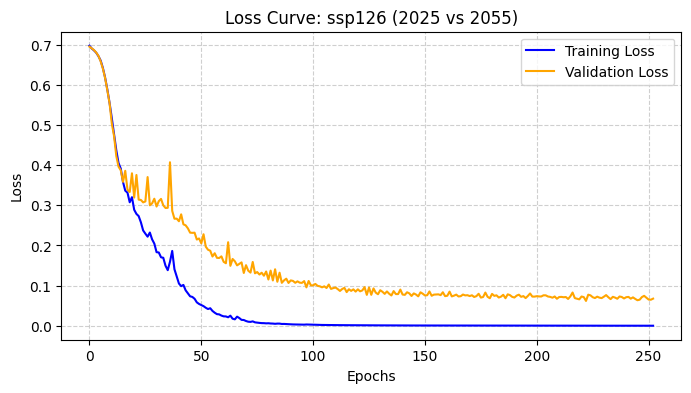

2/2 [==============================] - 0s 71ms/step
--> Iteration Accuracy: 94.00%
1/1 [==============================] - 0s 26ms/step
final accuracy:  94.00%
Processing: ssp126 | Early: 2025 | Late: 2065
processing model: CNRM_ESM2-1


C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 [==============================] - 4s 475ms/step - loss: 0.6946 - accuracy: 0.5475 - val_loss: 0.6870 - val_accuracy: 0.6200
Epoch 2/500
7/7 [==============================] - 3s 444ms/step - loss: 0.6836 - accuracy: 0.5425 - val_loss: 0.6808 - val_accuracy: 0.5200
Epoch 3/500
7/7 [==============================] - 3s 443ms/step - loss: 0.6758 - accuracy: 0.5050 - val_loss: 0.6720 - val_accuracy: 0.5200
Epoch 4/500
7/7 [==============================] - 3s 444ms/step - loss: 0.6632 - accuracy: 0.5025 - val_loss: 0.6618 - val_accuracy: 0.5000
Epoch 5/500
7/7 [==============================] - 3s 441ms/step - loss: 0.6479 - accuracy: 0.5025 - val_loss: 0.6515 - val_accuracy: 0.5000
Epoch 6/500
7/7 [==============================] - 3s 442ms/step - loss: 0.6310 - accuracy: 0.5050 - val_loss: 0.6426 - val_accuracy: 0.5200
Epoch 7/500
7/7 [=====================

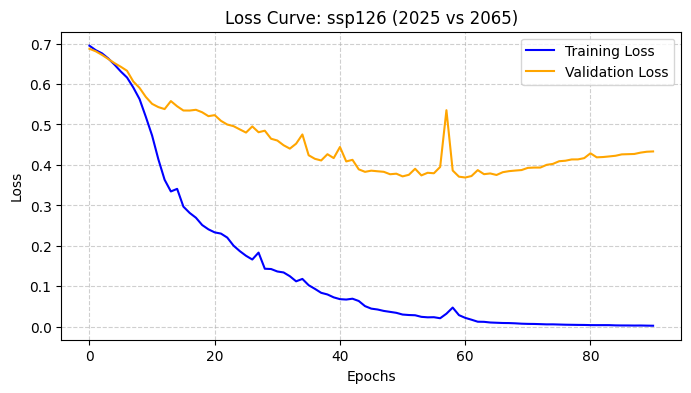

2/2 [==============================] - 0s 20ms/step
--> Iteration Accuracy: 94.00%
1/1 [==============================] - 0s 27ms/step
final accuracy:  94.00%
Processing: ssp126 | Early: 2025 | Late: 2075
processing model: CNRM_ESM2-1


C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 [==============================] - 2s 143ms/step - loss: 0.6887 - accuracy: 0.5100 - val_loss: 0.6864 - val_accuracy: 0.5000
Epoch 2/500
7/7 [==============================] - 1s 106ms/step - loss: 0.6806 - accuracy: 0.5000 - val_loss: 0.6795 - val_accuracy: 0.5000
Epoch 3/500
7/7 [==============================] - 1s 106ms/step - loss: 0.6696 - accuracy: 0.5000 - val_loss: 0.6703 - val_accuracy: 0.5000
Epoch 4/500
7/7 [==============================] - 1s 105ms/step - loss: 0.6540 - accuracy: 0.5000 - val_loss: 0.6597 - val_accuracy: 0.5000
Epoch 5/500
7/7 [==============================] - 1s 106ms/step - loss: 0.6382 - accuracy: 0.5025 - val_loss: 0.6497 - val_accuracy: 0.5000
Epoch 6/500
7/7 [==============================] - 1s 107ms/step - loss: 0.6191 - accuracy: 0.5175 - val_loss: 0.6380 - val_accuracy: 0.6000
Epoch 7/500
7/7 [=====================

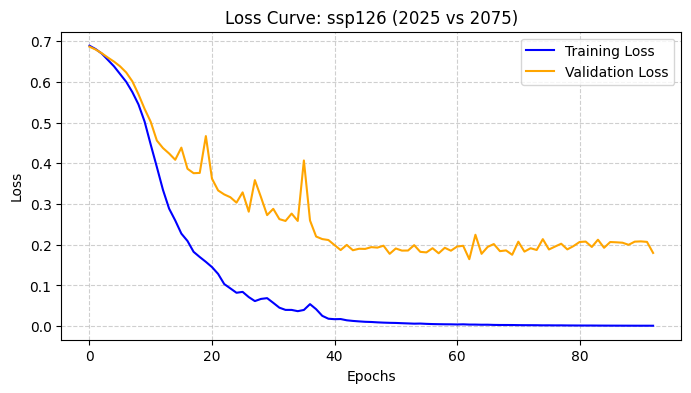

2/2 [==============================] - 0s 20ms/step
--> Iteration Accuracy: 98.00%
1/1 [==============================] - 0s 31ms/step
final accuracy:  98.00%
Processing: ssp126 | Early: 2025 | Late: 2085
processing model: CNRM_ESM2-1


C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 [==============================] - 4s 470ms/step - loss: 0.6898 - accuracy: 0.5075 - val_loss: 0.6852 - val_accuracy: 0.5200
Epoch 2/500
7/7 [==============================] - 3s 444ms/step - loss: 0.6825 - accuracy: 0.5225 - val_loss: 0.6787 - val_accuracy: 0.5200
Epoch 3/500
7/7 [==============================] - 3s 443ms/step - loss: 0.6747 - accuracy: 0.5425 - val_loss: 0.6689 - val_accuracy: 0.5200
Epoch 4/500
7/7 [==============================] - 3s 441ms/step - loss: 0.6634 - accuracy: 0.5475 - val_loss: 0.6539 - val_accuracy: 0.5200
Epoch 5/500
7/7 [==============================] - 3s 445ms/step - loss: 0.6472 - accuracy: 0.5900 - val_loss: 0.6337 - val_accuracy: 0.5600
Epoch 6/500
7/7 [==============================] - 3s 442ms/step - loss: 0.6247 - accuracy: 0.6650 - val_loss: 0.6052 - val_accuracy: 0.6400
Epoch 7/500
7/7 [=====================

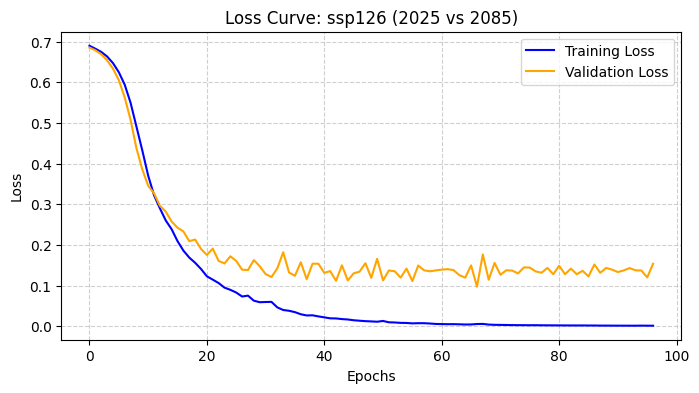

2/2 [==============================] - 0s 70ms/step
--> Iteration Accuracy: 98.00%
1/1 [==============================] - 0s 24ms/step
final accuracy:  98.00%
Processing: ssp126 | Early: 2035 | Late: 2045
processing model: CNRM_ESM2-1


C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 [==============================] - 4s 474ms/step - loss: 0.6939 - accuracy: 0.5050 - val_loss: 0.6934 - val_accuracy: 0.5000
Epoch 2/500
7/7 [==============================] - 3s 444ms/step - loss: 0.6903 - accuracy: 0.5075 - val_loss: 0.6921 - val_accuracy: 0.5000
Epoch 3/500
7/7 [==============================] - 3s 444ms/step - loss: 0.6876 - accuracy: 0.5050 - val_loss: 0.6907 - val_accuracy: 0.5000
Epoch 4/500
7/7 [==============================] - 3s 442ms/step - loss: 0.6855 - accuracy: 0.5100 - val_loss: 0.6900 - val_accuracy: 0.5000
Epoch 5/500
7/7 [==============================] - 3s 442ms/step - loss: 0.6831 - accuracy: 0.5025 - val_loss: 0.6889 - val_accuracy: 0.5000
Epoch 6/500
7/7 [==============================] - 3s 441ms/step - loss: 0.6806 - accuracy: 0.5075 - val_loss: 0.6881 - val_accuracy: 0.5000
Epoch 7/500
7/7 [=====================

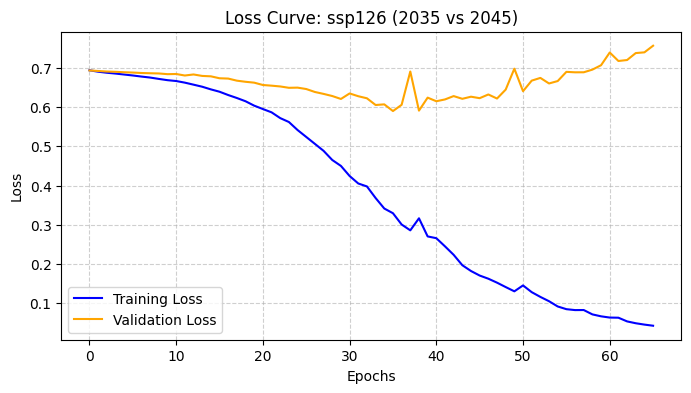

2/2 [==============================] - 0s 21ms/step
--> Iteration Accuracy: 60.00%
1/1 [==============================] - 0s 24ms/step
final accuracy:  60.00%
Processing: ssp126 | Early: 2035 | Late: 2055
processing model: CNRM_ESM2-1


C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 [==============================] - 2s 168ms/step - loss: 0.6988 - accuracy: 0.5000 - val_loss: 0.6944 - val_accuracy: 0.5000
Epoch 2/500
7/7 [==============================] - 1s 135ms/step - loss: 0.6931 - accuracy: 0.5100 - val_loss: 0.6936 - val_accuracy: 0.4600
Epoch 3/500
7/7 [==============================] - 1s 135ms/step - loss: 0.6901 - accuracy: 0.5625 - val_loss: 0.6933 - val_accuracy: 0.4800
Epoch 4/500
7/7 [==============================] - 1s 135ms/step - loss: 0.6878 - accuracy: 0.5475 - val_loss: 0.6923 - val_accuracy: 0.5000
Epoch 5/500
7/7 [==============================] - 1s 137ms/step - loss: 0.6852 - accuracy: 0.5275 - val_loss: 0.6908 - val_accuracy: 0.5000
Epoch 6/500
7/7 [==============================] - 1s 136ms/step - loss: 0.6820 - accuracy: 0.5575 - val_loss: 0.6881 - val_accuracy: 0.5600
Epoch 7/500
7/7 [=====================

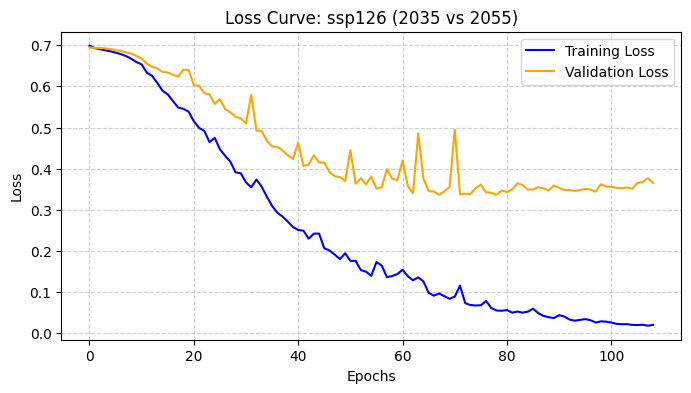

2/2 [==============================] - 0s 19ms/step
--> Iteration Accuracy: 84.00%
1/1 [==============================] - 0s 21ms/step
final accuracy:  84.00%
Processing: ssp126 | Early: 2035 | Late: 2065
processing model: CNRM_ESM2-1


C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 [==============================] - 2s 169ms/step - loss: 0.6905 - accuracy: 0.5000 - val_loss: 0.6885 - val_accuracy: 0.5000
Epoch 2/500
7/7 [==============================] - 1s 136ms/step - loss: 0.6877 - accuracy: 0.5000 - val_loss: 0.6854 - val_accuracy: 0.5000
Epoch 3/500
7/7 [==============================] - 1s 138ms/step - loss: 0.6834 - accuracy: 0.5000 - val_loss: 0.6828 - val_accuracy: 0.5000
Epoch 4/500
7/7 [==============================] - 1s 138ms/step - loss: 0.6804 - accuracy: 0.5000 - val_loss: 0.6796 - val_accuracy: 0.5000
Epoch 5/500
7/7 [==============================] - 1s 140ms/step - loss: 0.6786 - accuracy: 0.5000 - val_loss: 0.6768 - val_accuracy: 0.5000
Epoch 6/500
7/7 [==============================] - 1s 140ms/step - loss: 0.6738 - accuracy: 0.5000 - val_loss: 0.6746 - val_accuracy: 0.5000
Epoch 7/500
7/7 [=====================

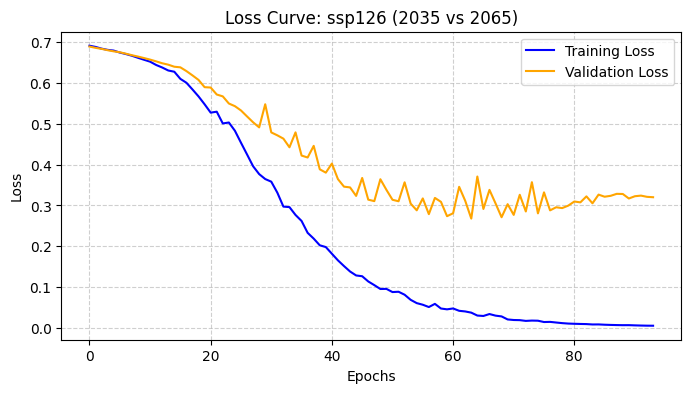

2/2 [==============================] - 0s 21ms/step
--> Iteration Accuracy: 94.00%
1/1 [==============================] - 0s 25ms/step
final accuracy:  94.00%
Processing: ssp126 | Early: 2035 | Late: 2075
processing model: CNRM_ESM2-1


C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 [==============================] - 4s 473ms/step - loss: 0.6906 - accuracy: 0.5050 - val_loss: 0.6880 - val_accuracy: 0.5000
Epoch 2/500
7/7 [==============================] - 3s 446ms/step - loss: 0.6879 - accuracy: 0.5000 - val_loss: 0.6849 - val_accuracy: 0.5000
Epoch 3/500
7/7 [==============================] - 3s 445ms/step - loss: 0.6838 - accuracy: 0.5000 - val_loss: 0.6813 - val_accuracy: 0.5000
Epoch 4/500
7/7 [==============================] - 3s 442ms/step - loss: 0.6803 - accuracy: 0.5025 - val_loss: 0.6760 - val_accuracy: 0.5000
Epoch 5/500
7/7 [==============================] - 3s 443ms/step - loss: 0.6749 - accuracy: 0.5025 - val_loss: 0.6727 - val_accuracy: 0.5000
Epoch 6/500
7/7 [==============================] - 3s 444ms/step - loss: 0.6703 - accuracy: 0.5075 - val_loss: 0.6682 - val_accuracy: 0.5000
Epoch 7/500
7/7 [=====================

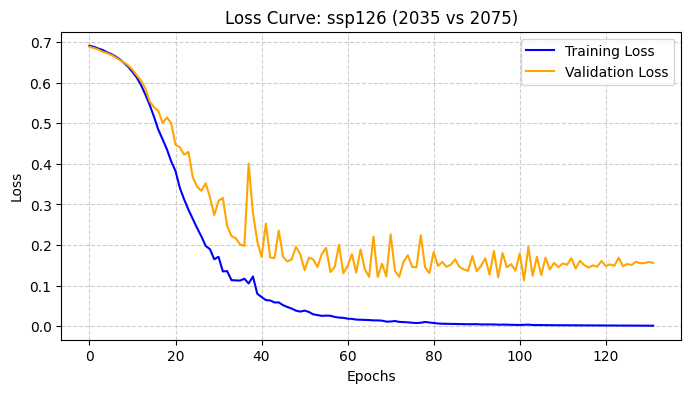

2/2 [==============================] - 0s 72ms/step
--> Iteration Accuracy: 100.00%
1/1 [==============================] - 0s 30ms/step
final accuracy:  100.00%
Processing: ssp126 | Early: 2035 | Late: 2085
processing model: CNRM_ESM2-1


C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 [==============================] - 4s 473ms/step - loss: 0.6934 - accuracy: 0.4875 - val_loss: 0.6934 - val_accuracy: 0.3800
Epoch 2/500
7/7 [==============================] - 3s 445ms/step - loss: 0.6906 - accuracy: 0.5925 - val_loss: 0.6923 - val_accuracy: 0.4400
Epoch 3/500
7/7 [==============================] - 3s 443ms/step - loss: 0.6884 - accuracy: 0.5750 - val_loss: 0.6913 - val_accuracy: 0.5000
Epoch 4/500
7/7 [==============================] - 3s 441ms/step - loss: 0.6860 - accuracy: 0.5675 - val_loss: 0.6906 - val_accuracy: 0.4800
Epoch 5/500
7/7 [==============================] - 3s 444ms/step - loss: 0.6828 - accuracy: 0.6125 - val_loss: 0.6893 - val_accuracy: 0.5200
Epoch 6/500
7/7 [==============================] - 3s 442ms/step - loss: 0.6790 - accuracy: 0.6050 - val_loss: 0.6877 - val_accuracy: 0.6000
Epoch 7/500
7/7 [=====================

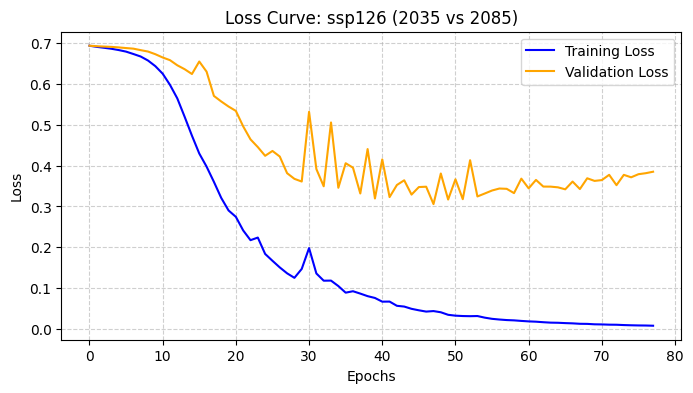

2/2 [==============================] - 0s 21ms/step
--> Iteration Accuracy: 88.00%
1/1 [==============================] - 0s 24ms/step
final accuracy:  88.00%
Processing: ssp126 | Early: 2045 | Late: 2055
processing model: CNRM_ESM2-1


C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 [==============================] - 2s 143ms/step - loss: 0.6953 - accuracy: 0.5000 - val_loss: 0.6949 - val_accuracy: 0.4800
Epoch 2/500
7/7 [==============================] - 1s 105ms/step - loss: 0.6919 - accuracy: 0.5150 - val_loss: 0.6952 - val_accuracy: 0.3800
Epoch 3/500
7/7 [==============================] - 1s 104ms/step - loss: 0.6900 - accuracy: 0.6000 - val_loss: 0.6953 - val_accuracy: 0.4200
Epoch 4/500
7/7 [==============================] - 1s 104ms/step - loss: 0.6881 - accuracy: 0.6450 - val_loss: 0.6951 - val_accuracy: 0.5200
Epoch 5/500
7/7 [==============================] - 1s 104ms/step - loss: 0.6864 - accuracy: 0.6300 - val_loss: 0.6957 - val_accuracy: 0.4600
Epoch 6/500
7/7 [==============================] - 1s 104ms/step - loss: 0.6848 - accuracy: 0.7000 - val_loss: 0.6954 - val_accuracy: 0.4800
Epoch 7/500
7/7 [=====================

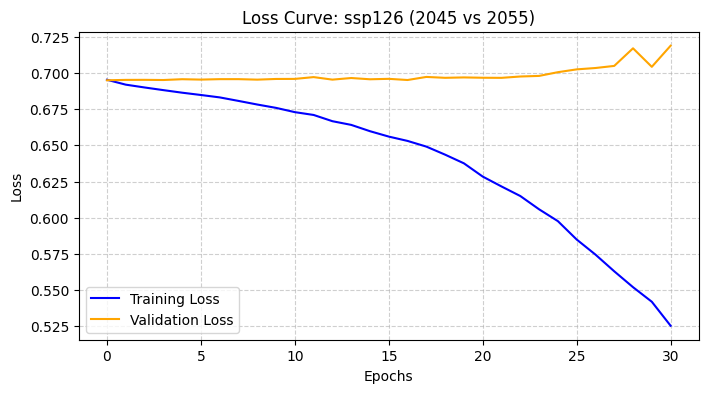

2/2 [==============================] - 0s 20ms/step
--> Iteration Accuracy: 52.00%
1/1 [==============================] - 0s 32ms/step
final accuracy:  52.00%
Processing: ssp126 | Early: 2045 | Late: 2065
processing model: CNRM_ESM2-1


C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 [==============================] - 2s 143ms/step - loss: 0.6932 - accuracy: 0.5150 - val_loss: 0.6938 - val_accuracy: 0.4600
Epoch 2/500
7/7 [==============================] - 1s 104ms/step - loss: 0.6918 - accuracy: 0.6400 - val_loss: 0.6939 - val_accuracy: 0.4800
Epoch 3/500
7/7 [==============================] - 1s 104ms/step - loss: 0.6910 - accuracy: 0.6750 - val_loss: 0.6944 - val_accuracy: 0.4600
Epoch 4/500
7/7 [==============================] - 1s 105ms/step - loss: 0.6897 - accuracy: 0.6750 - val_loss: 0.6941 - val_accuracy: 0.4800
Epoch 5/500
7/7 [==============================] - 1s 104ms/step - loss: 0.6884 - accuracy: 0.7250 - val_loss: 0.6944 - val_accuracy: 0.4400
Epoch 6/500
7/7 [==============================] - 1s 106ms/step - loss: 0.6872 - accuracy: 0.6975 - val_loss: 0.6947 - val_accuracy: 0.4600
Epoch 7/500
7/7 [=====================

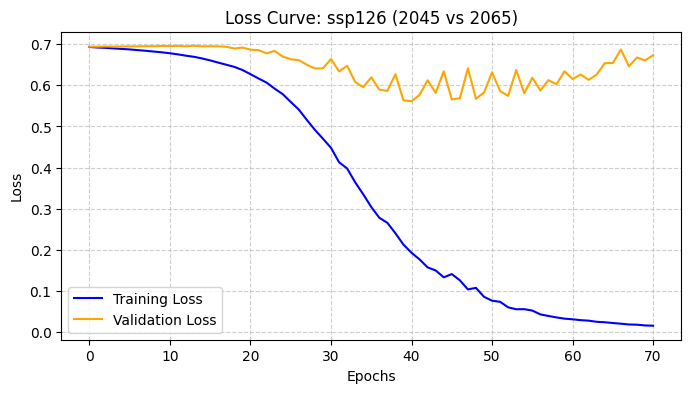

2/2 [==============================] - 0s 20ms/step
--> Iteration Accuracy: 78.00%
1/1 [==============================] - 0s 29ms/step
final accuracy:  78.00%
Processing: ssp126 | Early: 2045 | Late: 2075
processing model: CNRM_ESM2-1


C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 [==============================] - 2s 145ms/step - loss: 0.6929 - accuracy: 0.4875 - val_loss: 0.6929 - val_accuracy: 0.5000
Epoch 2/500
7/7 [==============================] - 1s 107ms/step - loss: 0.6896 - accuracy: 0.5000 - val_loss: 0.6908 - val_accuracy: 0.5000
Epoch 3/500
7/7 [==============================] - 1s 105ms/step - loss: 0.6871 - accuracy: 0.5000 - val_loss: 0.6890 - val_accuracy: 0.5000
Epoch 4/500
7/7 [==============================] - 1s 105ms/step - loss: 0.6842 - accuracy: 0.5150 - val_loss: 0.6875 - val_accuracy: 0.5000
Epoch 5/500
7/7 [==============================] - 1s 109ms/step - loss: 0.6815 - accuracy: 0.5125 - val_loss: 0.6856 - val_accuracy: 0.5000
Epoch 6/500
7/7 [==============================] - 1s 111ms/step - loss: 0.6789 - accuracy: 0.5200 - val_loss: 0.6829 - val_accuracy: 0.5200
Epoch 7/500
7/7 [=====================

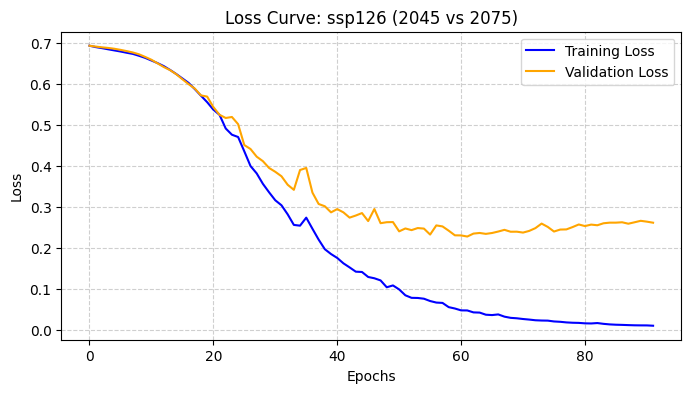

2/2 [==============================] - 0s 20ms/step
--> Iteration Accuracy: 86.00%
1/1 [==============================] - 0s 27ms/step
final accuracy:  86.00%
Processing: ssp126 | Early: 2045 | Late: 2085
processing model: CNRM_ESM2-1


C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 [==============================] - 4s 473ms/step - loss: 0.6979 - accuracy: 0.5000 - val_loss: 0.6929 - val_accuracy: 0.5000
Epoch 2/500
7/7 [==============================] - 3s 444ms/step - loss: 0.6931 - accuracy: 0.5025 - val_loss: 0.6915 - val_accuracy: 0.5400
Epoch 3/500
7/7 [==============================] - 3s 442ms/step - loss: 0.6915 - accuracy: 0.5175 - val_loss: 0.6911 - val_accuracy: 0.5800
Epoch 4/500
7/7 [==============================] - 3s 441ms/step - loss: 0.6898 - accuracy: 0.5725 - val_loss: 0.6899 - val_accuracy: 0.6400
Epoch 5/500
7/7 [==============================] - 3s 441ms/step - loss: 0.6876 - accuracy: 0.5425 - val_loss: 0.6883 - val_accuracy: 0.5400
Epoch 6/500
7/7 [==============================] - 3s 443ms/step - loss: 0.6861 - accuracy: 0.5100 - val_loss: 0.6872 - val_accuracy: 0.5600
Epoch 7/500
7/7 [=====================

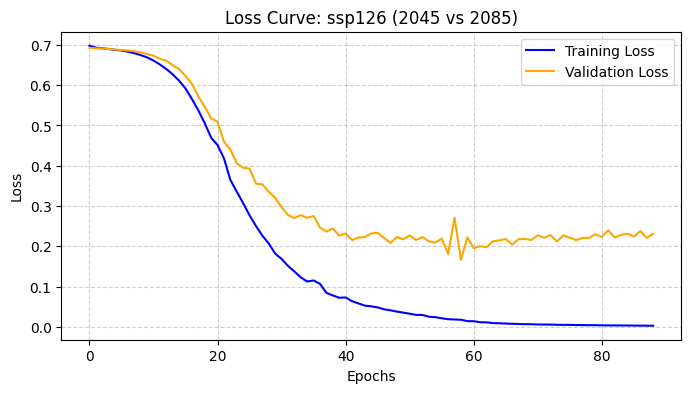

2/2 [==============================] - 0s 20ms/step
--> Iteration Accuracy: 92.00%
1/1 [==============================] - 0s 22ms/step
final accuracy:  92.00%
Processing: ssp126 | Early: 2055 | Late: 2065
processing model: CNRM_ESM2-1


C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 [==============================] - 3s 245ms/step - loss: 0.6940 - accuracy: 0.5000 - val_loss: 0.6888 - val_accuracy: 0.5200
Epoch 2/500
7/7 [==============================] - 1s 111ms/step - loss: 0.6898 - accuracy: 0.5025 - val_loss: 0.6872 - val_accuracy: 0.5200
Epoch 3/500
7/7 [==============================] - 1s 109ms/step - loss: 0.6874 - accuracy: 0.5150 - val_loss: 0.6878 - val_accuracy: 0.5000
Epoch 4/500
7/7 [==============================] - 1s 108ms/step - loss: 0.6855 - accuracy: 0.5525 - val_loss: 0.6873 - val_accuracy: 0.6000
Epoch 5/500
7/7 [==============================] - 1s 112ms/step - loss: 0.6832 - accuracy: 0.5875 - val_loss: 0.6878 - val_accuracy: 0.5000
Epoch 6/500
7/7 [==============================] - 1s 115ms/step - loss: 0.6823 - accuracy: 0.5050 - val_loss: 0.6872 - val_accuracy: 0.5000
Epoch 7/500
7/7 [=====================

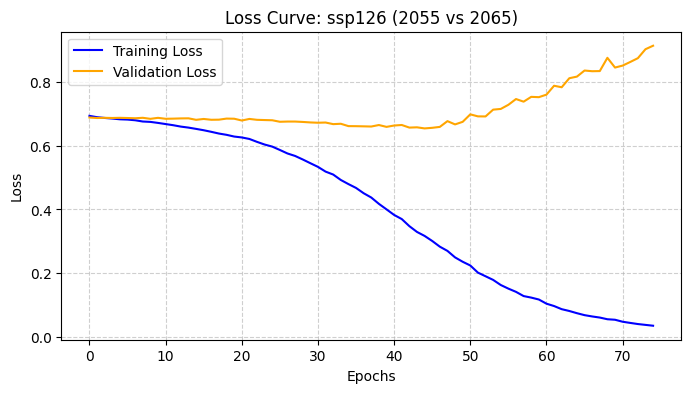

2/2 [==============================] - 0s 20ms/step
--> Iteration Accuracy: 60.00%
1/1 [==============================] - 0s 26ms/step
final accuracy:  60.00%
Processing: ssp126 | Early: 2055 | Late: 2075
processing model: CNRM_ESM2-1


C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 [==============================] - 2s 143ms/step - loss: 0.6925 - accuracy: 0.4900 - val_loss: 0.6903 - val_accuracy: 0.5000
Epoch 2/500
7/7 [==============================] - 1s 104ms/step - loss: 0.6883 - accuracy: 0.5050 - val_loss: 0.6904 - val_accuracy: 0.5000
Epoch 3/500
7/7 [==============================] - 1s 105ms/step - loss: 0.6845 - accuracy: 0.5375 - val_loss: 0.6895 - val_accuracy: 0.5200
Epoch 4/500
7/7 [==============================] - 1s 105ms/step - loss: 0.6808 - accuracy: 0.6425 - val_loss: 0.6895 - val_accuracy: 0.5000
Epoch 5/500
7/7 [==============================] - 1s 106ms/step - loss: 0.6765 - accuracy: 0.6475 - val_loss: 0.6892 - val_accuracy: 0.5000
Epoch 6/500
7/7 [==============================] - 1s 108ms/step - loss: 0.6722 - accuracy: 0.6725 - val_loss: 0.6874 - val_accuracy: 0.5000
Epoch 7/500
7/7 [=====================

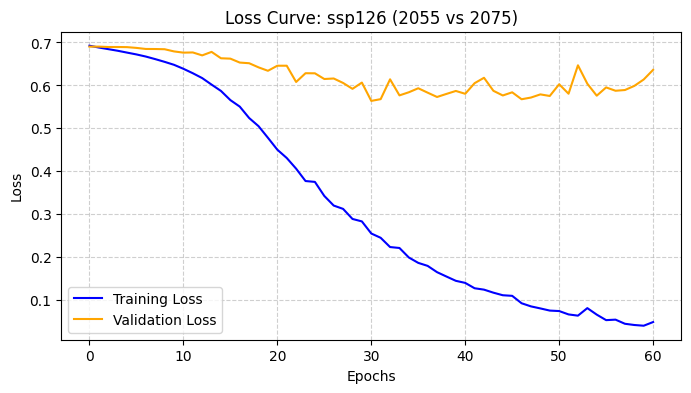

2/2 [==============================] - 0s 20ms/step
--> Iteration Accuracy: 76.00%
1/1 [==============================] - 0s 24ms/step
final accuracy:  76.00%
Processing: ssp126 | Early: 2055 | Late: 2085
processing model: CNRM_ESM2-1


C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 [==============================] - 2s 147ms/step - loss: 0.6918 - accuracy: 0.5275 - val_loss: 0.6888 - val_accuracy: 0.7200
Epoch 2/500
7/7 [==============================] - 1s 106ms/step - loss: 0.6881 - accuracy: 0.6200 - val_loss: 0.6879 - val_accuracy: 0.6200
Epoch 3/500
7/7 [==============================] - 1s 106ms/step - loss: 0.6837 - accuracy: 0.6075 - val_loss: 0.6866 - val_accuracy: 0.6200
Epoch 4/500
7/7 [==============================] - 1s 106ms/step - loss: 0.6788 - accuracy: 0.5925 - val_loss: 0.6834 - val_accuracy: 0.6000
Epoch 5/500
7/7 [==============================] - 1s 105ms/step - loss: 0.6721 - accuracy: 0.5750 - val_loss: 0.6815 - val_accuracy: 0.5800
Epoch 6/500
7/7 [==============================] - 1s 107ms/step - loss: 0.6643 - accuracy: 0.5425 - val_loss: 0.6787 - val_accuracy: 0.5600
Epoch 7/500
7/7 [=====================

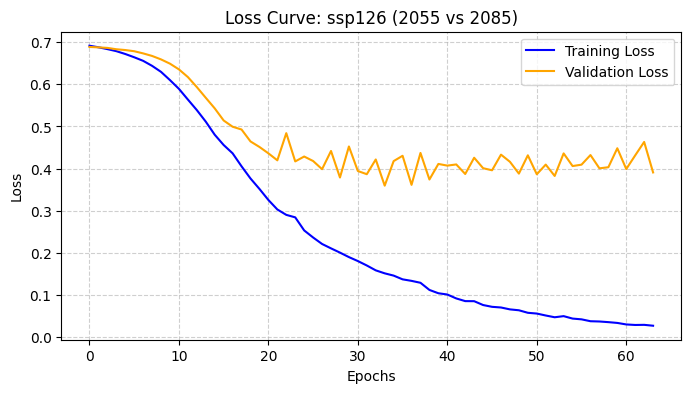

2/2 [==============================] - 0s 20ms/step
--> Iteration Accuracy: 88.00%
1/1 [==============================] - 0s 26ms/step
final accuracy:  88.00%
Processing: ssp126 | Early: 2065 | Late: 2075
processing model: CNRM_ESM2-1


C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 [==============================] - 2s 155ms/step - loss: 0.6941 - accuracy: 0.5000 - val_loss: 0.6907 - val_accuracy: 0.5000
Epoch 2/500
7/7 [==============================] - 1s 108ms/step - loss: 0.6907 - accuracy: 0.5000 - val_loss: 0.6895 - val_accuracy: 0.5000
Epoch 3/500
7/7 [==============================] - 1s 106ms/step - loss: 0.6890 - accuracy: 0.5000 - val_loss: 0.6896 - val_accuracy: 0.5000
Epoch 4/500
7/7 [==============================] - 1s 108ms/step - loss: 0.6870 - accuracy: 0.5000 - val_loss: 0.6884 - val_accuracy: 0.5000
Epoch 5/500
7/7 [==============================] - 1s 106ms/step - loss: 0.6853 - accuracy: 0.5025 - val_loss: 0.6881 - val_accuracy: 0.5000
Epoch 6/500
7/7 [==============================] - 1s 108ms/step - loss: 0.6835 - accuracy: 0.5025 - val_loss: 0.6869 - val_accuracy: 0.5000
Epoch 7/500
7/7 [=====================

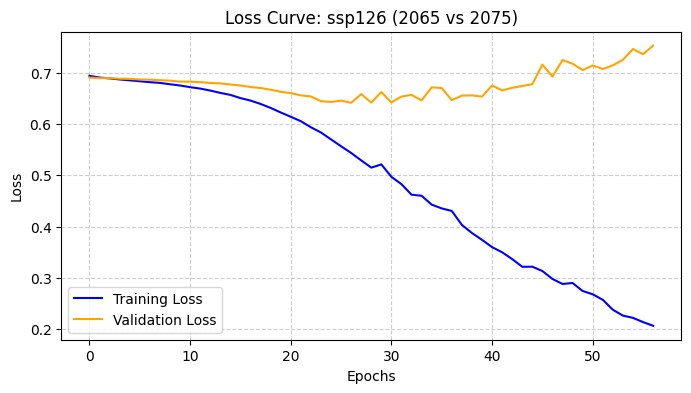

2/2 [==============================] - 0s 21ms/step
--> Iteration Accuracy: 50.00%
1/1 [==============================] - 0s 48ms/step
final accuracy:  50.00%
Processing: ssp126 | Early: 2065 | Late: 2085
processing model: CNRM_ESM2-1


C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 [==============================] - 2s 144ms/step - loss: 0.6940 - accuracy: 0.4850 - val_loss: 0.6949 - val_accuracy: 0.4000
Epoch 2/500
7/7 [==============================] - 1s 106ms/step - loss: 0.6925 - accuracy: 0.5150 - val_loss: 0.6955 - val_accuracy: 0.4000
Epoch 3/500
7/7 [==============================] - 1s 104ms/step - loss: 0.6906 - accuracy: 0.6150 - val_loss: 0.6959 - val_accuracy: 0.4400
Epoch 4/500
7/7 [==============================] - 1s 104ms/step - loss: 0.6887 - accuracy: 0.6275 - val_loss: 0.6967 - val_accuracy: 0.3800
Epoch 5/500
7/7 [==============================] - 1s 104ms/step - loss: 0.6863 - accuracy: 0.6325 - val_loss: 0.6964 - val_accuracy: 0.3800
Epoch 6/500
7/7 [==============================] - 1s 109ms/step - loss: 0.6831 - accuracy: 0.6600 - val_loss: 0.6960 - val_accuracy: 0.3400
Epoch 7/500
7/7 [=====================

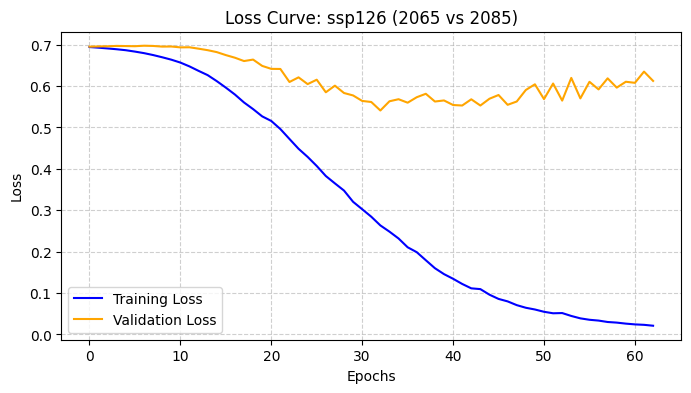

2/2 [==============================] - 0s 20ms/step
--> Iteration Accuracy: 82.00%
1/1 [==============================] - 0s 26ms/step
final accuracy:  82.00%
Processing: ssp126 | Early: 2075 | Late: 2085
processing model: CNRM_ESM2-1


C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
C:\Users\student\AppData\Local\Temp\ipykernel_15452\925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 [==============================] - 2s 149ms/step - loss: 0.6939 - accuracy: 0.5000 - val_loss: 0.6944 - val_accuracy: 0.5000
Epoch 2/500
7/7 [==============================] - 1s 104ms/step - loss: 0.6911 - accuracy: 0.5000 - val_loss: 0.6950 - val_accuracy: 0.5000
Epoch 3/500
7/7 [==============================] - 1s 104ms/step - loss: 0.6894 - accuracy: 0.5000 - val_loss: 0.6954 - val_accuracy: 0.5000
Epoch 4/500
7/7 [==============================] - 1s 103ms/step - loss: 0.6877 - accuracy: 0.5000 - val_loss: 0.6949 - val_accuracy: 0.5000
Epoch 5/500
7/7 [==============================] - 1s 106ms/step - loss: 0.6863 - accuracy: 0.5000 - val_loss: 0.6949 - val_accuracy: 0.5000
Epoch 6/500
7/7 [==============================] - 1s 112ms/step - loss: 0.6847 - accuracy: 0.5025 - val_loss: 0.6953 - val_accuracy: 0.5000
Epoch 7/500
7/7 [=====================

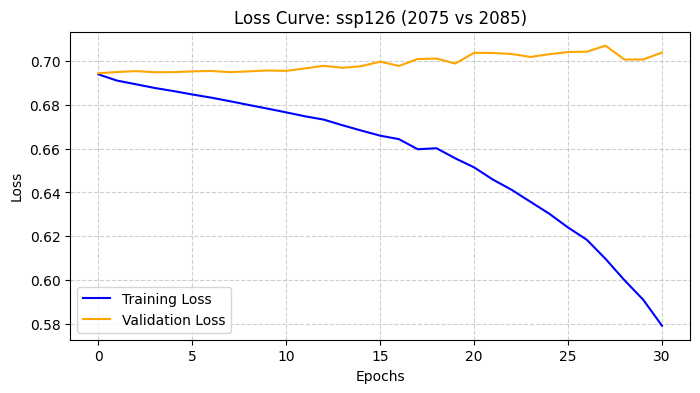

2/2 [==============================] - 0s 20ms/step
--> Iteration Accuracy: 50.00%
1/1 [==============================] - 0s 26ms/step
final accuracy:  50.00%
DONE!


In [9]:
results = run_climate_experiment(['ssp119', 'ssp126'], [2015, 2025, 2035, 2045, 2055, 2065, 2075], model_list, data_path) # Skip 2085, too late (cannot compare)
# 42 experiments, will take a while to run - suggested to run overnight
# Run this 10 times to generate and quantify uncertainty